In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import keras
from keras import layers

In [2]:
IMAGE_SIZE = 64
BATCH_SIZE = 128
LATENT_DIM = 100
EPOCHS = 150
CLASSES = 2

# Dataset Loading

In [3]:
# 1. Dataset Loading
(ds_train, ds_test), ds_info = tfds.load("cats_vs_dogs", split=["train[:90%]", "train[90%:]"], shuffle_files=True, as_supervised=True, with_info=True) #

def preprocess_image(image, label):
    # Resize to 64x64
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    # Introduce random horizontal flipping to real images
    image = tf.image.random_flip_left_right(image)
    # Normalize to [-1, 1]
    image = (image - 127.5) / 127.5
    # Ensure label is integer
    label = tf.cast(label, tf.int32)
    return image, label

# 2. Preprocessing Pipeline
# Add num_parallel_calls and increase shuffle buffer for better mixing
train_dataset = ds_train.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).shuffle(5000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = ds_test.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)

2026-03-01 16:53:56.795466: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-01 16:53:56.795484: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-01 16:53:56.795489: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-01 16:53:56.795511: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-01 16:53:56.795521: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


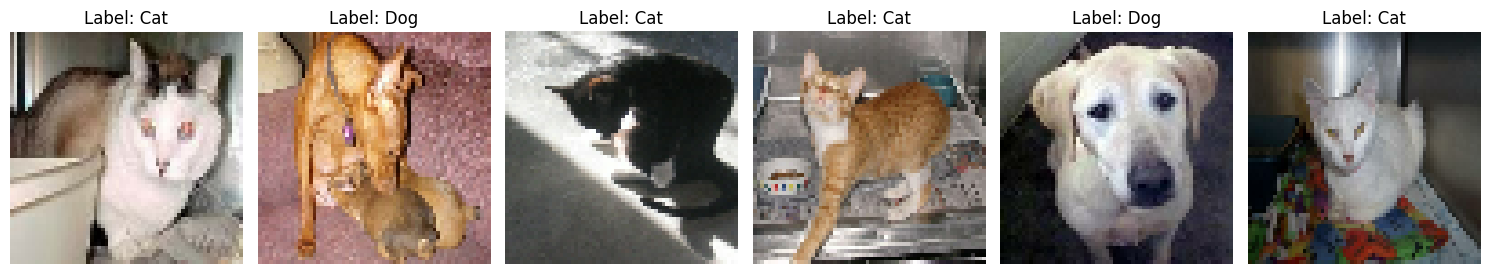

In [ ]:
def display_sample_images(dataset, num_samples=5):
    plt.figure(figsize=(15, 3))
    # Take one batch from the dataset
    for images, labels in dataset.take(1):
        for i in range(num_samples):
            plt.subplot(1, num_samples, i + 1)
            # Denormalize from [-1, 1] to [0, 1] for plotting
            img = (images[i].numpy() + 1) / 2.0
            plt.imshow(img)
            label_text = "Dog" if labels[i].numpy() == 1 else "Cat"
            plt.title(f"Label: {label_text}")
            plt.axis("off")
    plt.tight_layout()
    plt.show()

# Visualize samples from the training dataset
display_sample_images(train_dataset, num_samples=6)

# GAN Architecture

In [4]:
def build_generator(latent_dim, num_classes):
    # Inputs: Noise vector and Label
    target_label = layers.Input(shape=(1,), name="label_input")
    noise = layers.Input(shape=(latent_dim,), name="noise_input")

    # Label embedding: Map label to a vector space
    label_embedding = layers.Embedding(num_classes, latent_dim)(target_label)
    label_embedding = layers.Flatten()(label_embedding)

    # Combine noise and label
    combined_input = layers.Concatenate()([noise, label_embedding])

    # Foundation for 4x4 image
    x = layers.Dense(4 * 4 * 512, use_bias=False)(combined_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Reshape((4, 4, 512))(x)

    # Upsampling to 8x8, 16x16, 32x32, then 64x64
    x = layers.Conv2DTranspose(256, (4, 4), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Final output layer: 64x64x3 with tanh activation
    out = layers.Conv2DTranspose(3, (4, 4), strides=(2, 2), padding="same", activation="tanh")(x)

    return keras.Model([noise, target_label], out, name="generator")

generator = build_generator(LATENT_DIM, CLASSES)

In [5]:
def build_discriminator(img_shape, num_classes):
    # Inputs: Image and Label
    img_input = layers.Input(shape=img_shape, name="image_input")
    label_input = layers.Input(shape=(1,), name="label_input")

    # Embed label and reshape to match image dimensions for concatenation
    label_embedding = layers.Embedding(num_classes, 64 * 64)(label_input)
    label_embedding = layers.Reshape((64, 64, 1))(label_embedding)

    # Concatenate label channel to image
    # Deliberately using Concatenate to allow the discriminator to learn how to use label information, 
    # rather than forcing it through multiplication which might be too restrictive.
    combined_input = layers.Concatenate()([img_input, label_embedding])

    # Downsample: 64x64 -> 32x32 -> 16x16 -> 8x8
    x = layers.Conv2D(64, (4, 4), strides=(2, 2), padding="same")(combined_input)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(128, (4, 4), strides=(2, 2), padding="same")(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, (4, 4), strides=(2, 2), padding="same")(x)
    x = layers.LeakyReLU()(x)

    # Final Classification
    x = layers.Flatten()(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model([img_input, label_input], out, name="discriminator")

discriminator = build_discriminator(img_shape=(64, 64, 3), num_classes=2)

# Loss Functions & Optimizer

In [6]:
cross_entropy = keras.losses.BinaryCrossentropy()

def discriminator_loss(real_output, fake_output):
    # Use one-sided label smoothing (0.9 instead of 1.0)
    real_loss = cross_entropy(tf.ones_like(real_output) * 0.9, real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Adam optimizers with a learning rate of 1e-4 and beta_1 of 0.5 are commonly used for GANs to stabilize training.
# Trying with different combinations of learning rates for generator and discriminator to see if it improves convergence.
gen_optimizer = keras.optimizers.legacy.Adam(5e-5, beta_1=0.5)
# Implement Two Time-Scale Update Rule (TTUR): Use different learning rates for generator and discriminator to improve convergence.
disc_optimizer = keras.optimizers.legacy.Adam(2e-4, beta_1=0.5)

In [7]:
# Print Model Summaries
print("Generator Summary:")
generator.summary()

print("\nDiscriminator Summary:")
discriminator.summary()

Generator Summary:
Model: "generator"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 label_input (InputLayer)    [(None, 1)]                  0         []                            
                                                                                                  
 embedding (Embedding)       (None, 1, 100)               200       ['label_input[0][0]']         
                                                                                                  
 noise_input (InputLayer)    [(None, 100)]                0         []                            
                                                                                                  
 flatten (Flatten)           (None, 100)                  0         ['embedding[0][0]']           
                                                                       

# Results Display

In [8]:
def generate_and_plot(num_examples=10):
    # Labels: 0 for Cat, 1 for Dog (randomly chosen for visualization)
    random_labels = tf.random.uniform((num_examples,), minval=0, maxval=2, dtype=tf.int32)
    noise = tf.random.normal([num_examples, LATENT_DIM])
    
    # Generate images
    generated_images = generator([noise, random_labels], training=False)
    
    # Rescale to [0, 1] for plotting
    generated_images = (generated_images + 1) / 2.0

    cols = 7  # Number of images per row
    rows = (num_examples + cols - 1) // cols  # Auto-calculate rows needed
    plt.figure(figsize=(cols * 4, rows * 4))  # 4 inches per image (width x height)    
    for i in range(num_examples):
        plt.subplot(rows, cols, i+1)
        plt.imshow(generated_images[i])
        label_text = "Dog" if random_labels[i] == 1 else "Cat"
        plt.title(f"Label: {label_text}")
        plt.axis("off")
        plt.tight_layout()
    plt.show()

# Model Tranining

2026-03-01 16:53:58.415351: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Epoch 1: Gen Loss: 3.1115, Disc Loss: 0.5204
Epoch 2: Gen Loss: 2.7067, Disc Loss: 0.6251
Epoch 3: Gen Loss: 2.3443, Disc Loss: 0.7121
Epoch 4: Gen Loss: 1.8702, Disc Loss: 0.8605
Epoch 5: Gen Loss: 1.7864, Disc Loss: 0.8353
Epoch 6: Gen Loss: 1.6630, Disc Loss: 0.9021
Epoch 7: Gen Loss: 1.5621, Disc Loss: 0.9447
Epoch 8: Gen Loss: 1.5100, Disc Loss: 0.9641
Epoch 9: Gen Loss: 1.5822, Disc Loss: 0.9718
Epoch 10: Gen Loss: 1.6020, Disc Loss: 0.9218


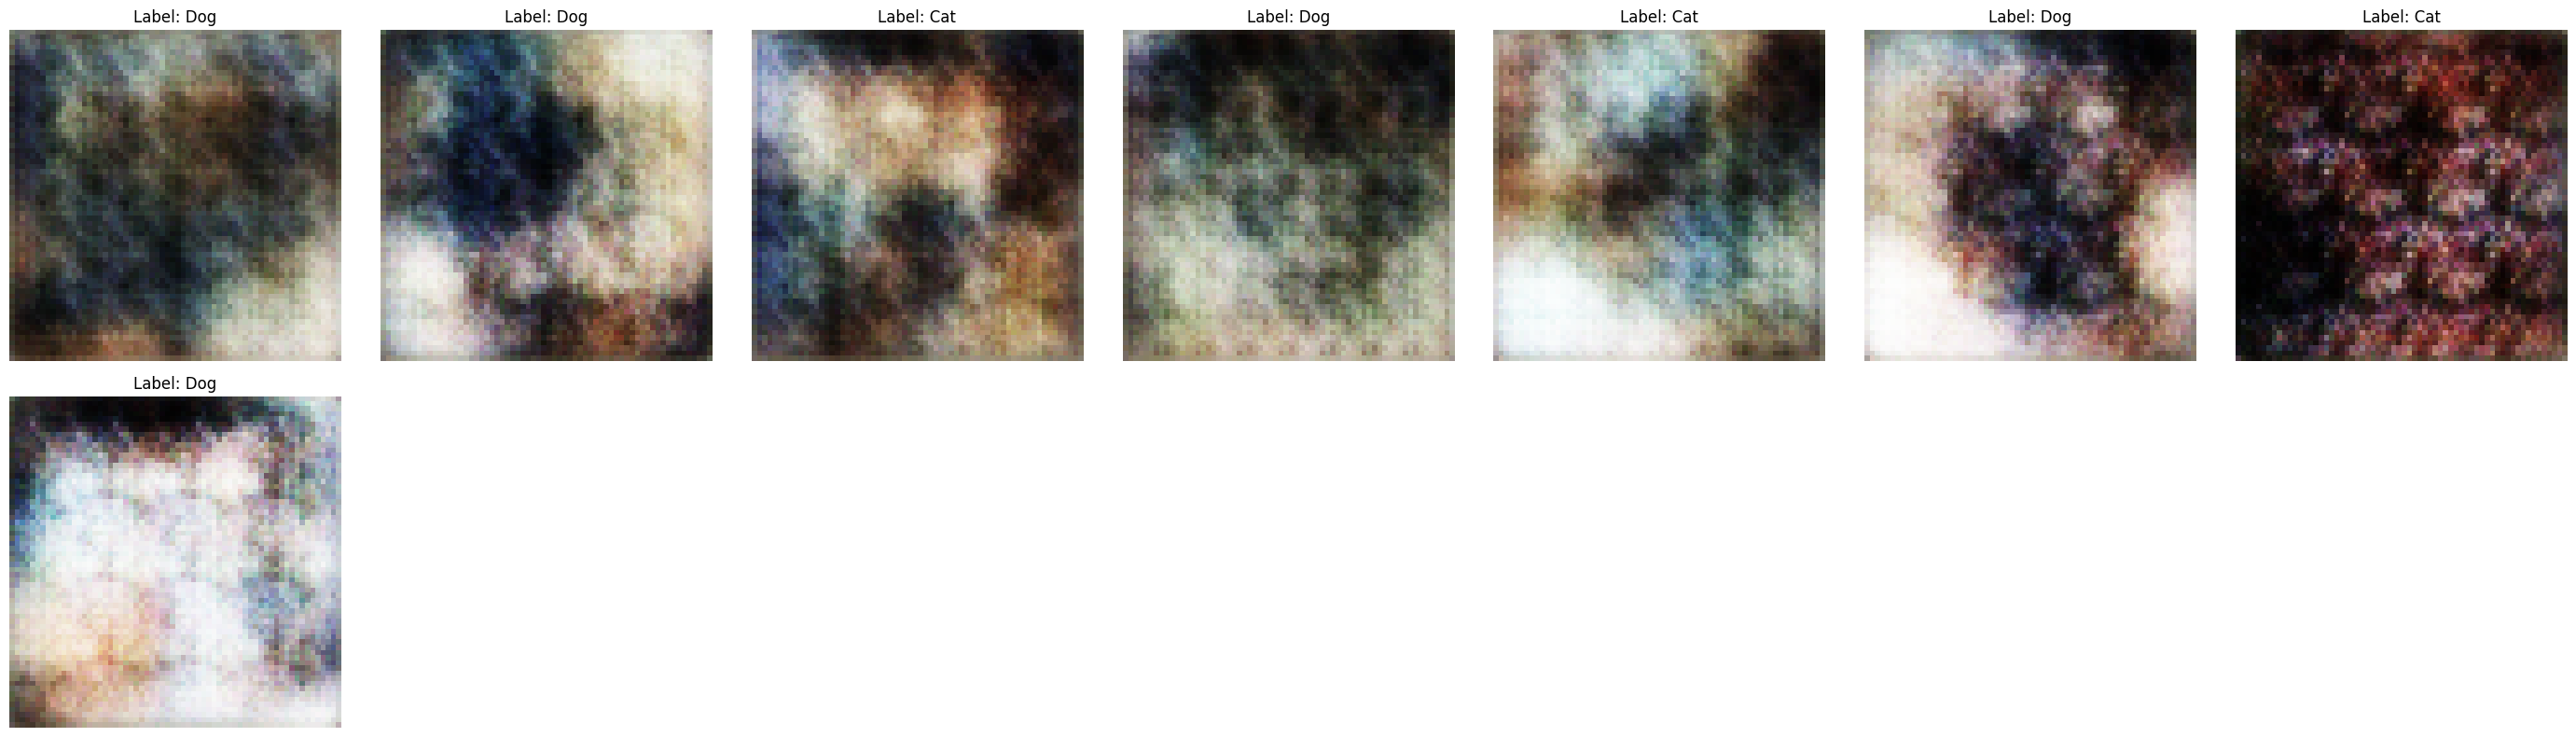

Epoch 11: Gen Loss: 1.4652, Disc Loss: 0.9741
Epoch 12: Gen Loss: 1.4994, Disc Loss: 1.0068
Epoch 13: Gen Loss: 1.4326, Disc Loss: 1.0359
Epoch 14: Gen Loss: 1.3919, Disc Loss: 1.0470
Epoch 15: Gen Loss: 1.2592, Disc Loss: 1.0978
Epoch 16: Gen Loss: 1.1992, Disc Loss: 1.1327
Epoch 17: Gen Loss: 1.1387, Disc Loss: 1.1789
Epoch 18: Gen Loss: 1.0962, Disc Loss: 1.1916
Epoch 19: Gen Loss: 1.0768, Disc Loss: 1.2169
Epoch 20: Gen Loss: 1.0584, Disc Loss: 1.2168


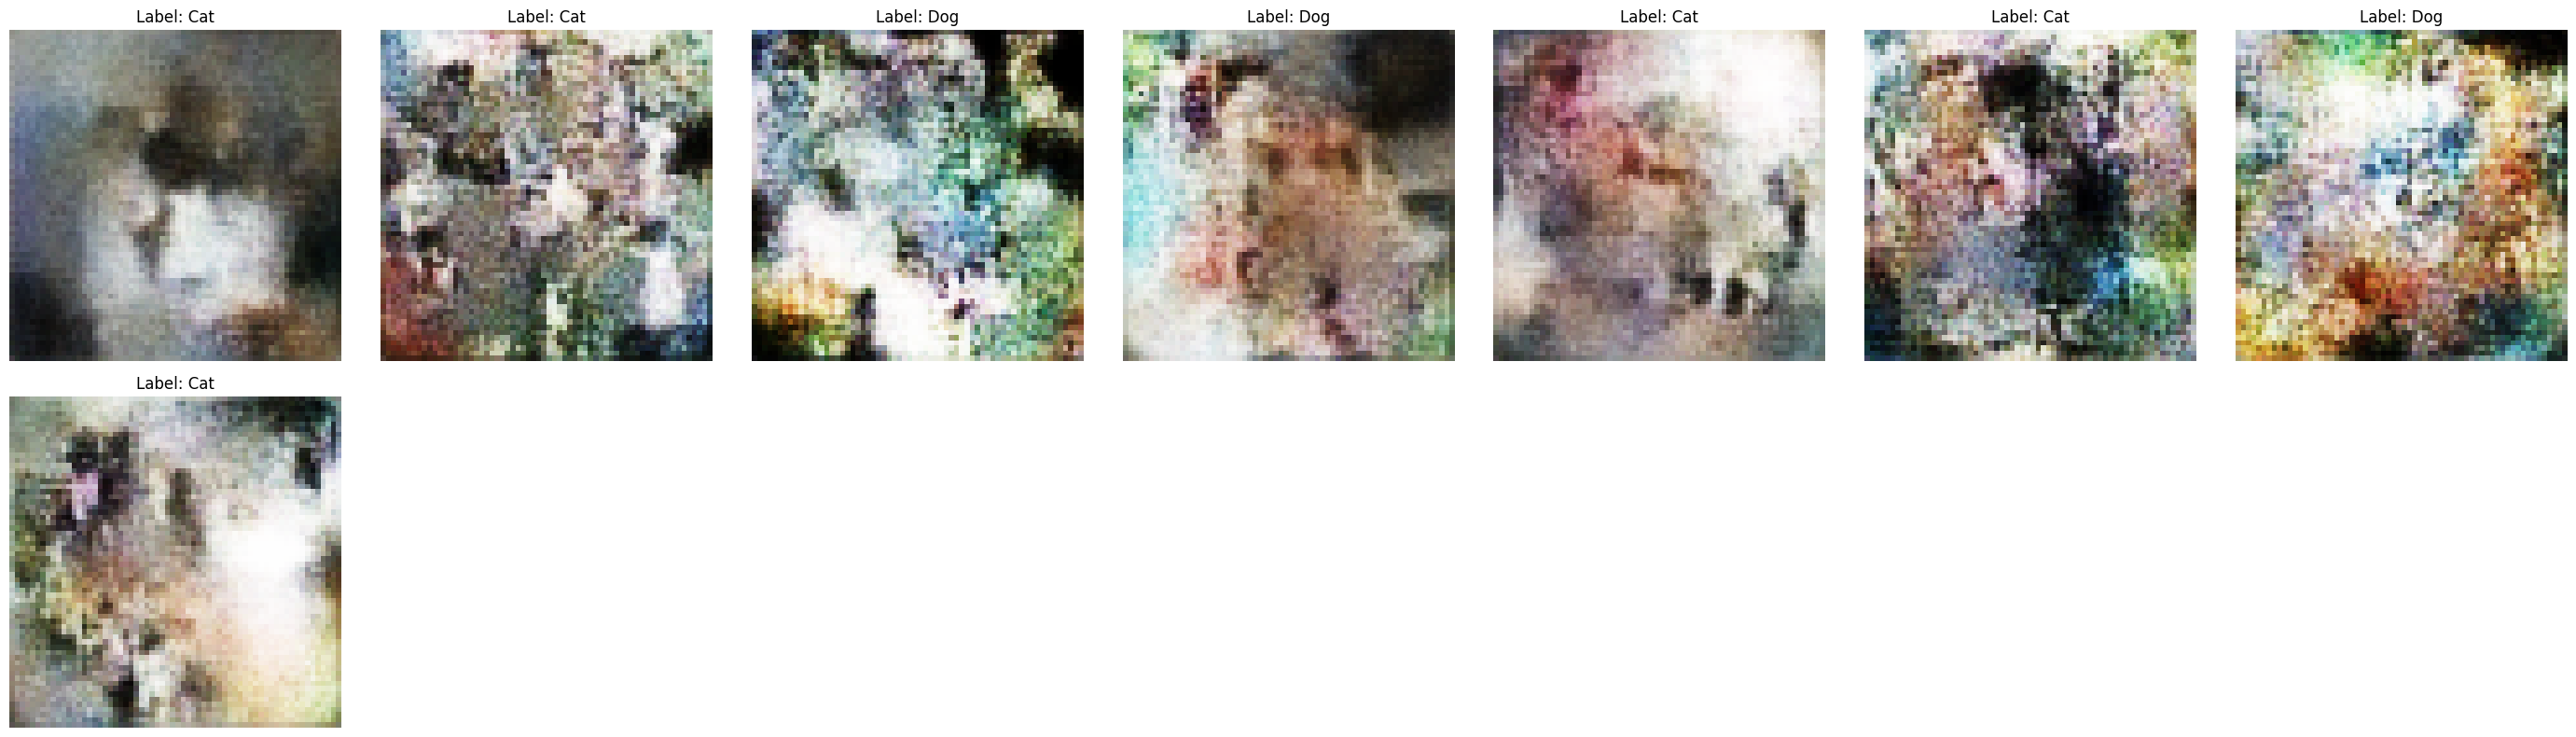

Epoch 21: Gen Loss: 1.0710, Disc Loss: 1.2152
Epoch 22: Gen Loss: 1.0517, Disc Loss: 1.2187
Epoch 23: Gen Loss: 1.0376, Disc Loss: 1.2426
Epoch 24: Gen Loss: 1.0548, Disc Loss: 1.2047
Epoch 25: Gen Loss: 1.0543, Disc Loss: 1.2017
Epoch 26: Gen Loss: 1.0699, Disc Loss: 1.2670
Epoch 27: Gen Loss: 1.0224, Disc Loss: 1.2100
Epoch 28: Gen Loss: 1.0368, Disc Loss: 1.2243
Epoch 29: Gen Loss: 1.0594, Disc Loss: 1.2307
Epoch 30: Gen Loss: 1.0412, Disc Loss: 1.2202


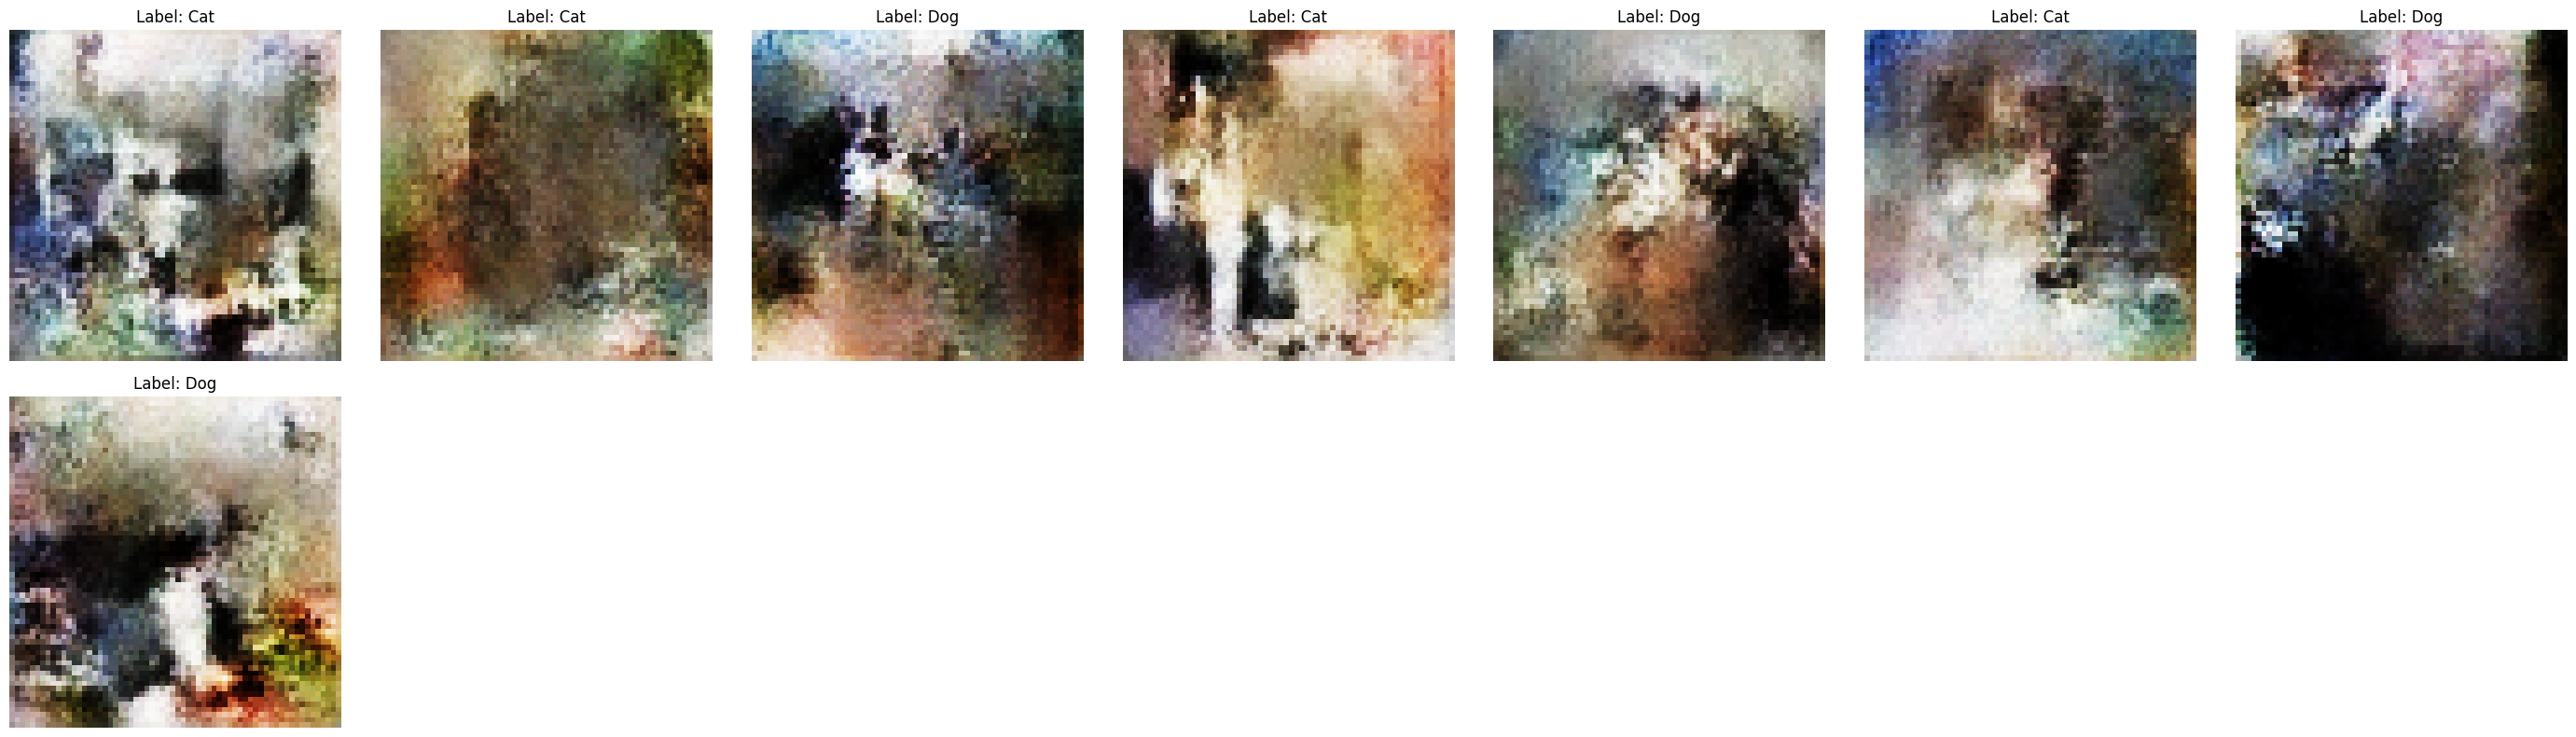

Epoch 31: Gen Loss: 1.0221, Disc Loss: 1.2265
Epoch 32: Gen Loss: 1.0201, Disc Loss: 1.2592
Epoch 33: Gen Loss: 1.0294, Disc Loss: 1.3166
Epoch 34: Gen Loss: 1.1498, Disc Loss: 1.1633
Epoch 35: Gen Loss: 1.0359, Disc Loss: 1.2060
Epoch 36: Gen Loss: 1.0201, Disc Loss: 1.2367
Epoch 37: Gen Loss: 1.0038, Disc Loss: 1.2477
Epoch 38: Gen Loss: 1.1089, Disc Loss: 1.2472
Epoch 39: Gen Loss: 1.0356, Disc Loss: 1.2557
Epoch 40: Gen Loss: 1.0185, Disc Loss: 1.2081


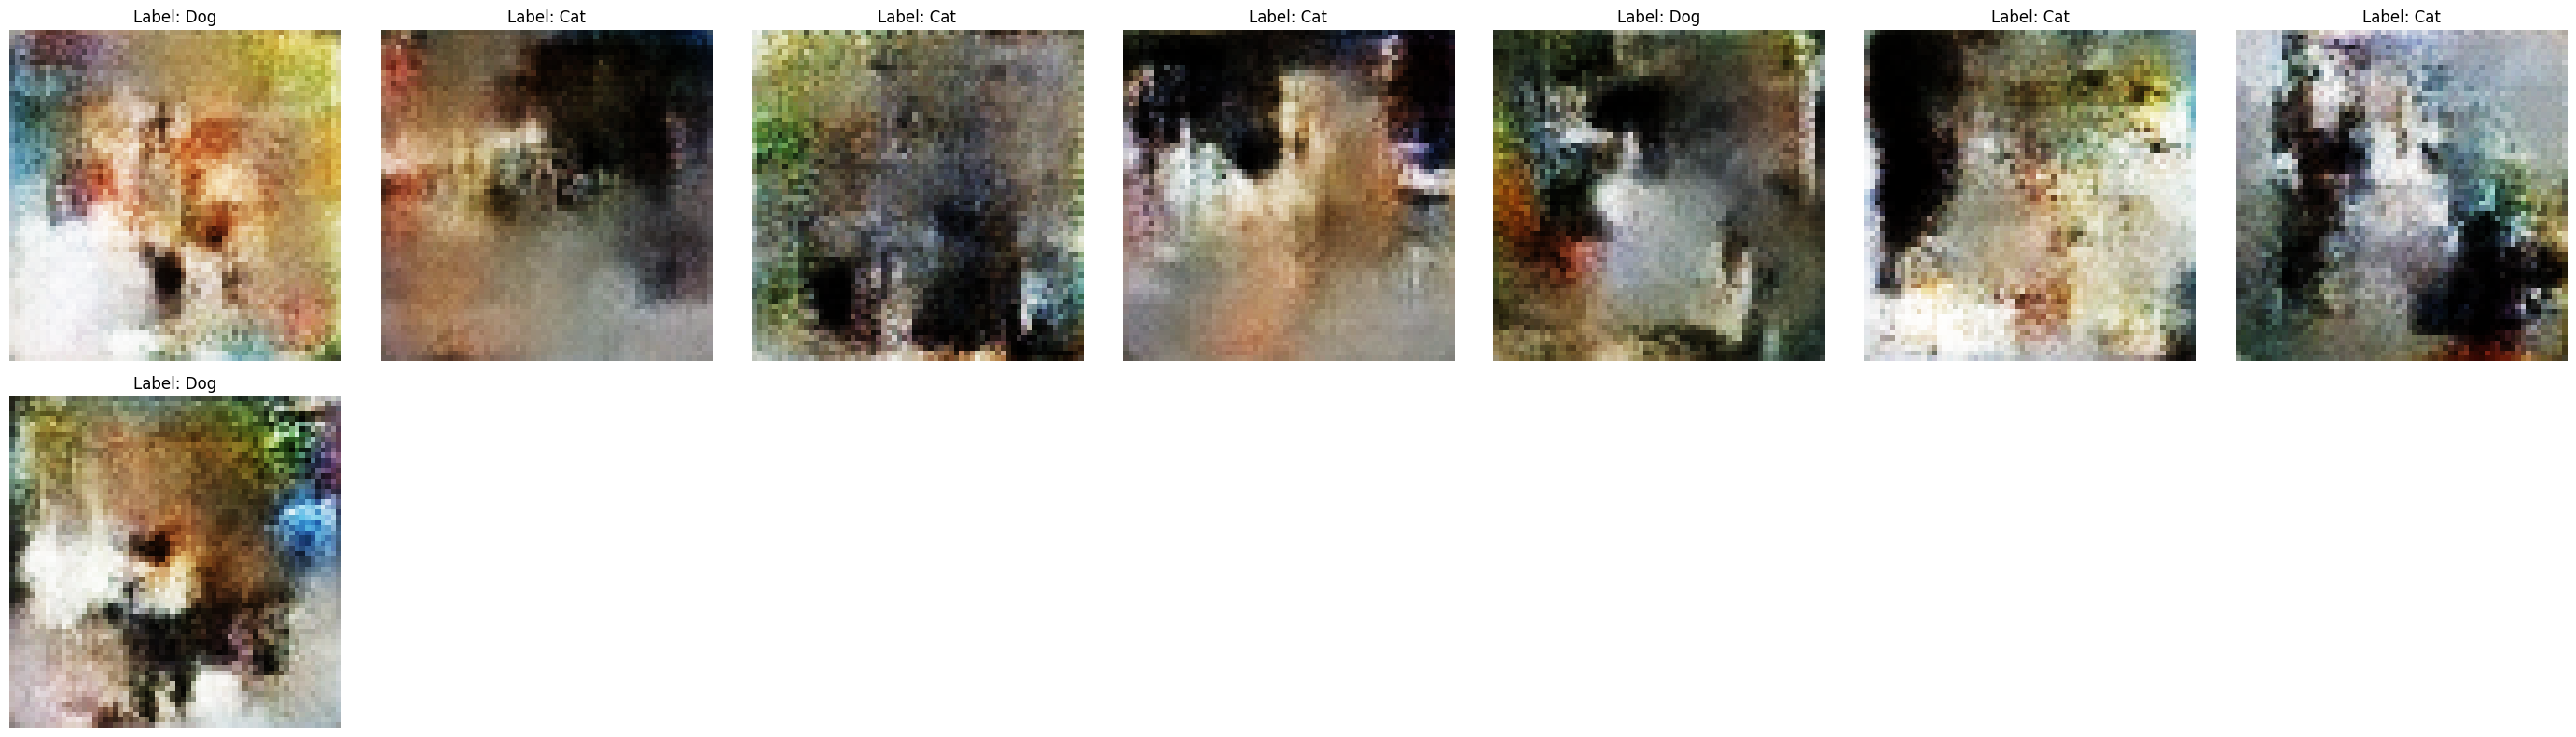

Epoch 41: Gen Loss: 1.0033, Disc Loss: 1.2295
Epoch 42: Gen Loss: 1.0247, Disc Loss: 1.2682
Epoch 43: Gen Loss: 0.9926, Disc Loss: 1.2411
Epoch 44: Gen Loss: 1.0818, Disc Loss: 1.2830
Epoch 45: Gen Loss: 1.1716, Disc Loss: 1.1677
Epoch 46: Gen Loss: 1.1336, Disc Loss: 1.1580
Epoch 47: Gen Loss: 1.0987, Disc Loss: 1.1750
Epoch 48: Gen Loss: 1.0495, Disc Loss: 1.2056
Epoch 49: Gen Loss: 1.0438, Disc Loss: 1.2815
Epoch 50: Gen Loss: 1.0084, Disc Loss: 1.2248


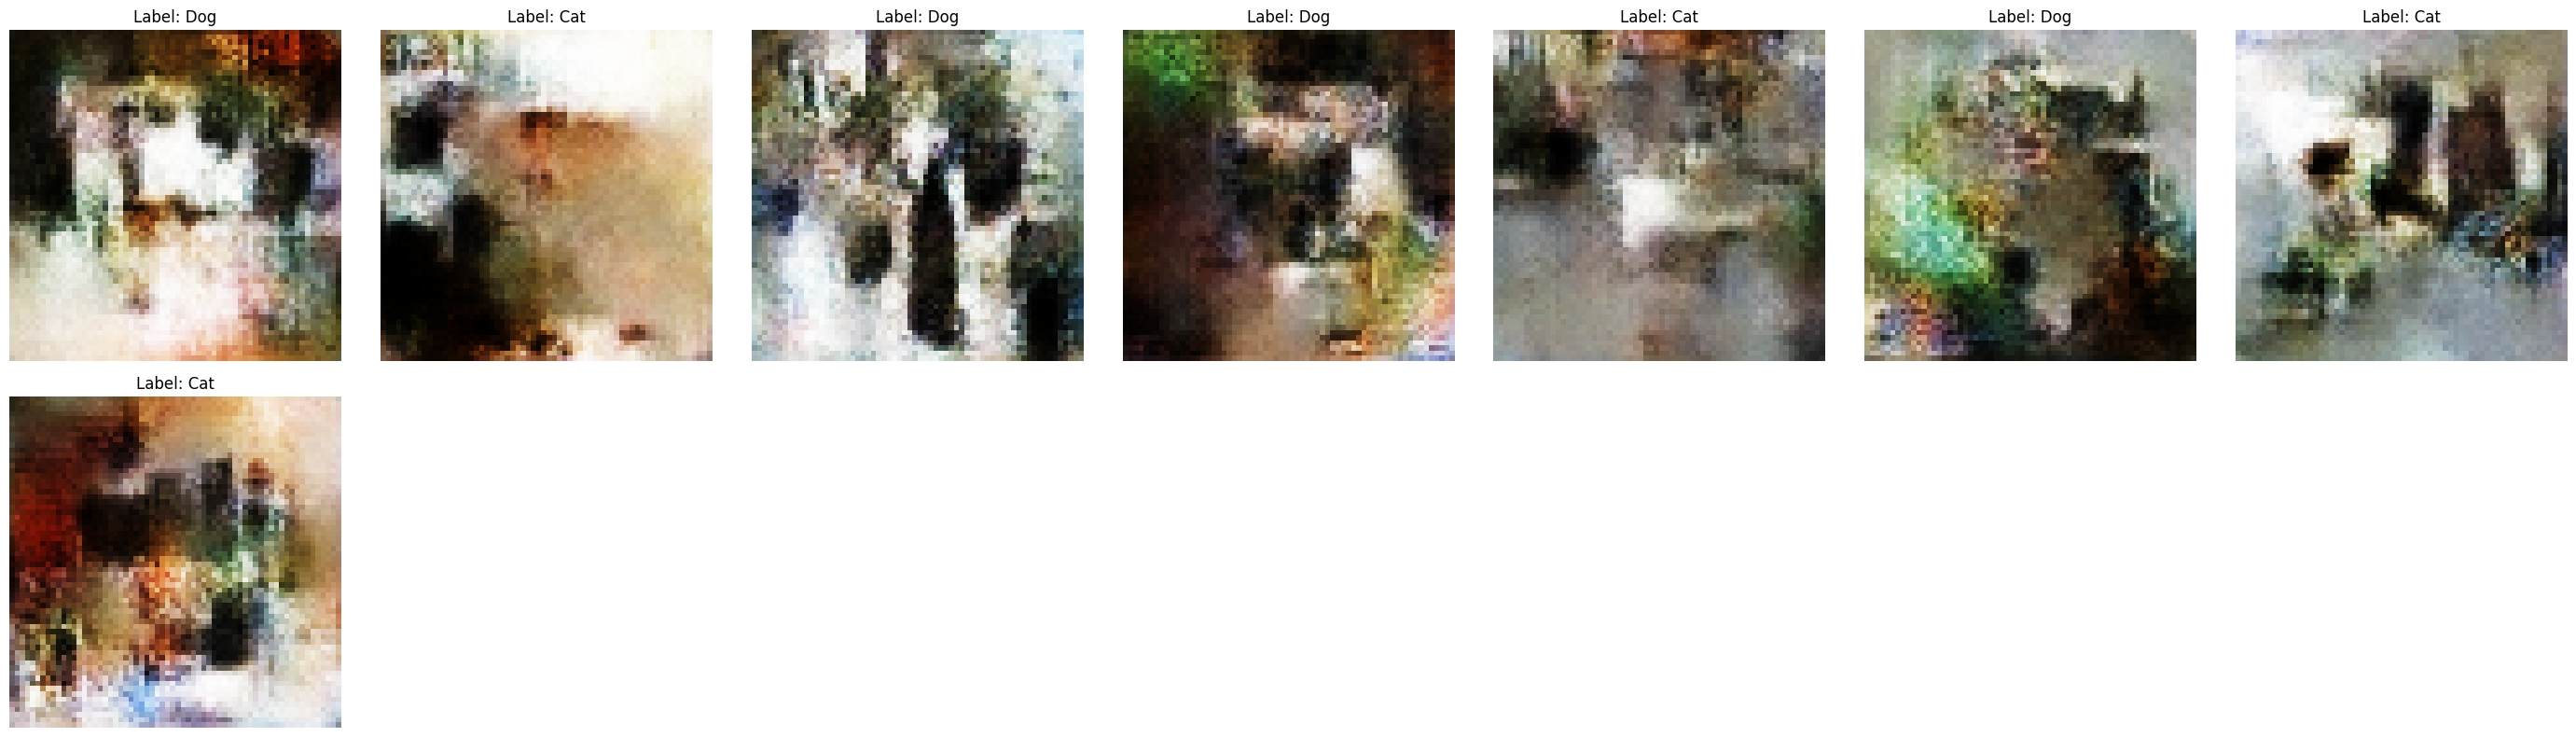

Epoch 51: Gen Loss: 0.9979, Disc Loss: 1.2520
Epoch 52: Gen Loss: 0.9873, Disc Loss: 1.2634
Epoch 53: Gen Loss: 0.9857, Disc Loss: 1.2675
Epoch 54: Gen Loss: 1.3935, Disc Loss: 1.1693
Epoch 55: Gen Loss: 1.3803, Disc Loss: 1.0808
Epoch 56: Gen Loss: 1.3634, Disc Loss: 1.0758
Epoch 57: Gen Loss: 1.2652, Disc Loss: 1.0980
Epoch 58: Gen Loss: 1.1533, Disc Loss: 1.1366
Epoch 59: Gen Loss: 1.0622, Disc Loss: 1.1926
Epoch 60: Gen Loss: 1.0577, Disc Loss: 1.2646


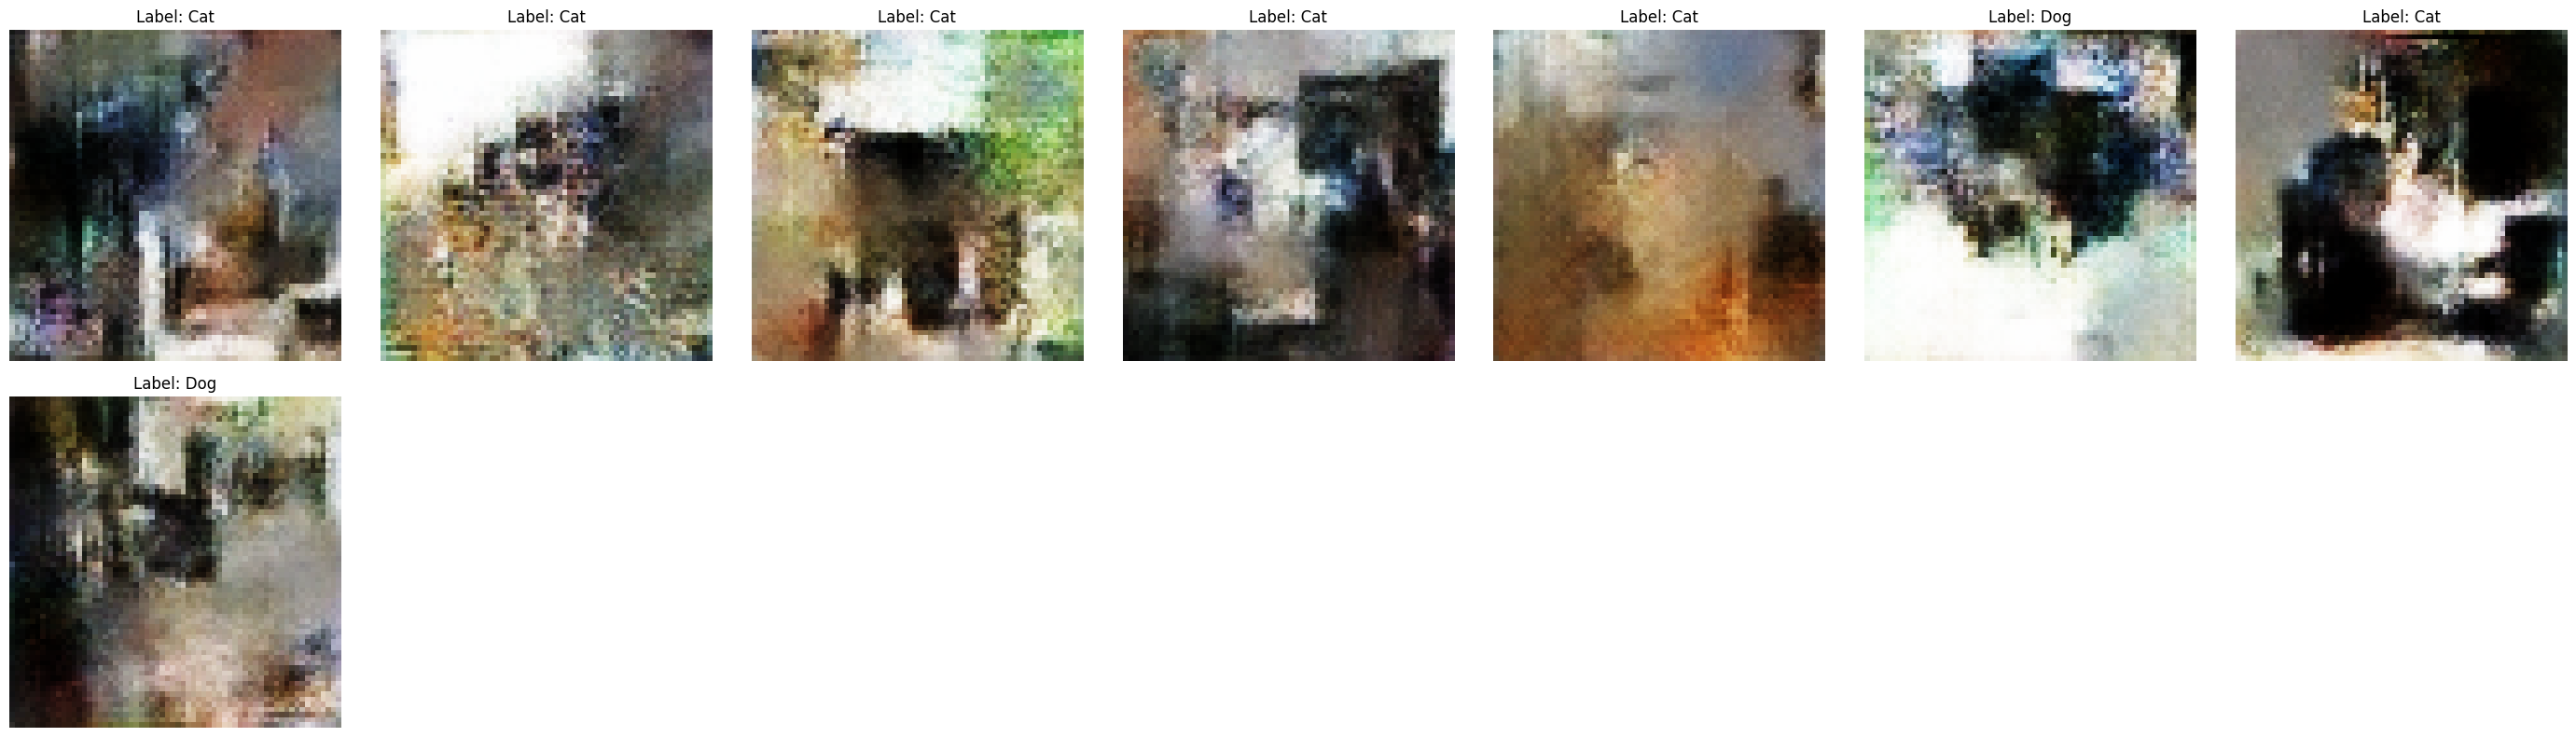

Epoch 61: Gen Loss: 1.0102, Disc Loss: 1.2257
Epoch 62: Gen Loss: 1.0158, Disc Loss: 1.2405
Epoch 63: Gen Loss: 1.0090, Disc Loss: 1.2596
Epoch 64: Gen Loss: 1.0247, Disc Loss: 1.3022
Epoch 65: Gen Loss: 1.0053, Disc Loss: 1.2272
Epoch 66: Gen Loss: 1.0329, Disc Loss: 1.2396
Epoch 67: Gen Loss: 1.0191, Disc Loss: 1.2699
Epoch 68: Gen Loss: 1.0148, Disc Loss: 1.2564
Epoch 69: Gen Loss: 0.9948, Disc Loss: 1.2244
Epoch 70: Gen Loss: 0.9919, Disc Loss: 1.2692


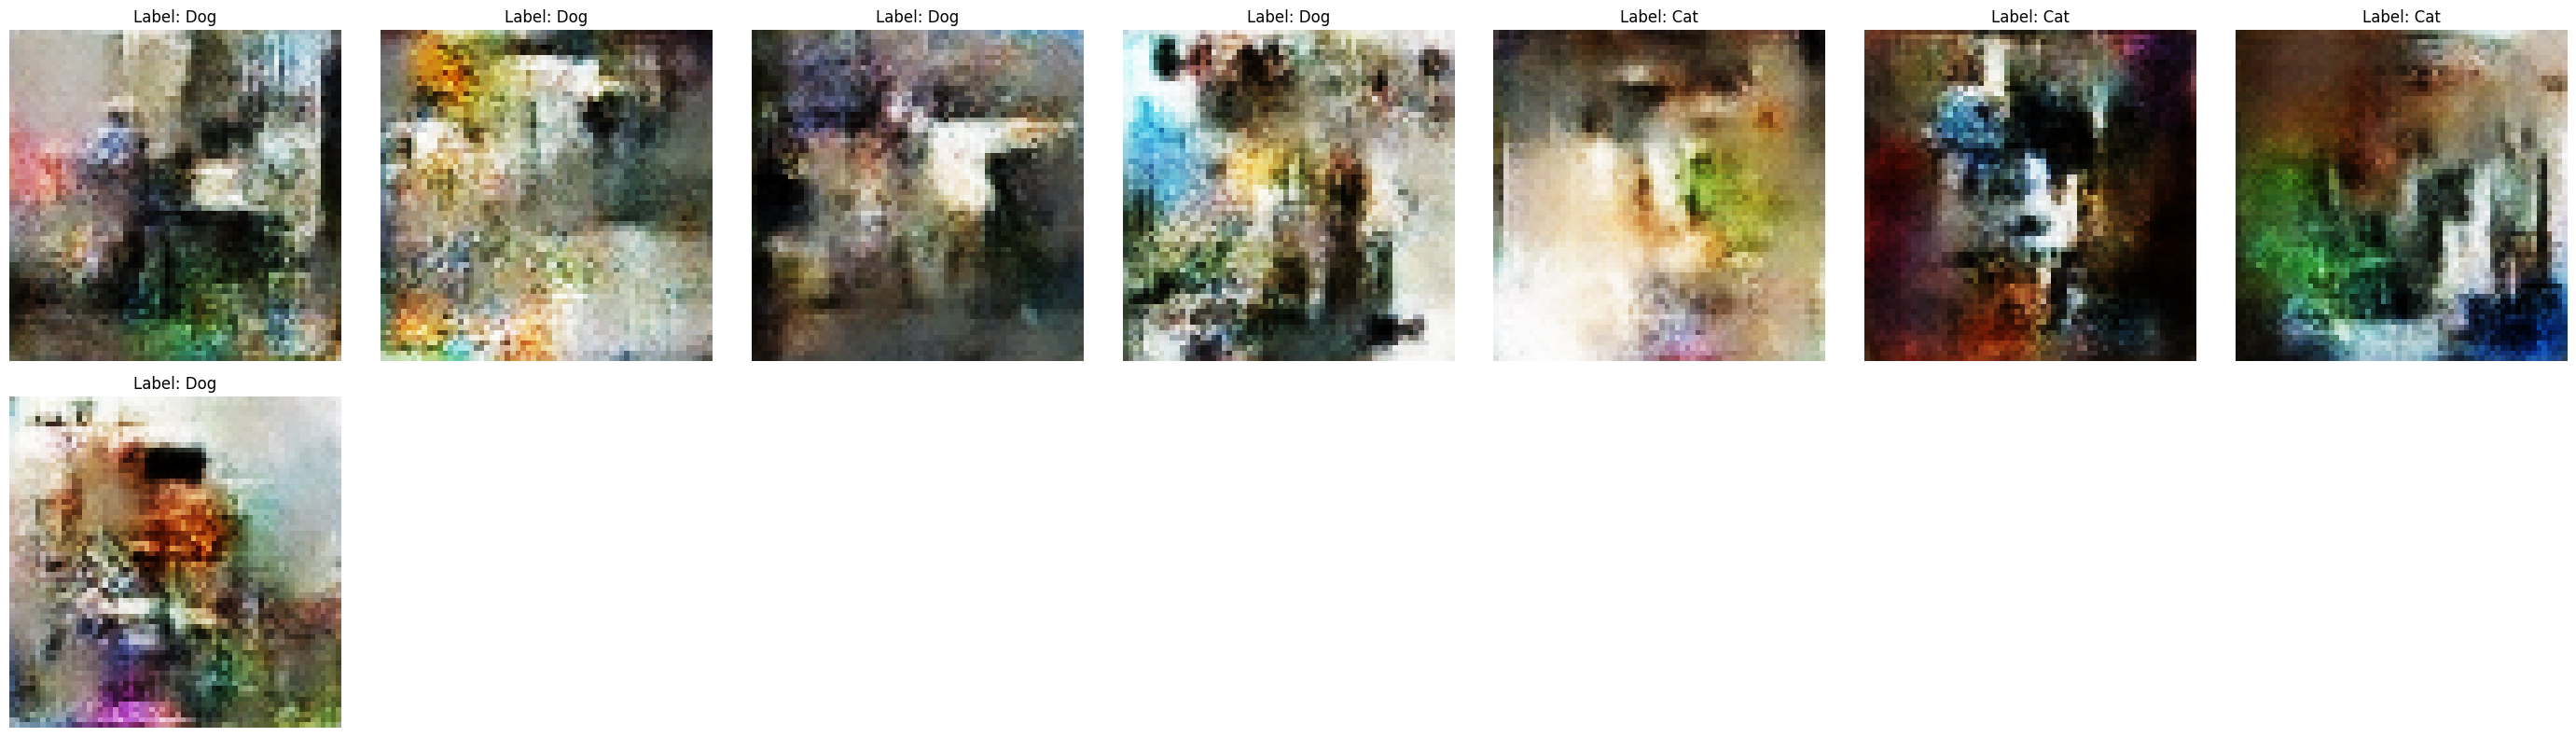

Epoch 71: Gen Loss: 0.9957, Disc Loss: 1.2586
Epoch 72: Gen Loss: 0.9934, Disc Loss: 1.2495
Epoch 73: Gen Loss: 0.9964, Disc Loss: 1.2539
Epoch 74: Gen Loss: 0.9976, Disc Loss: 1.2539
Epoch 75: Gen Loss: 1.0122, Disc Loss: 1.2704
Epoch 76: Gen Loss: 0.9980, Disc Loss: 1.2419
Epoch 77: Gen Loss: 1.0023, Disc Loss: 1.2599
Epoch 78: Gen Loss: 1.0027, Disc Loss: 1.2427
Epoch 79: Gen Loss: 0.9935, Disc Loss: 1.2536
Epoch 80: Gen Loss: 1.0005, Disc Loss: 1.2497


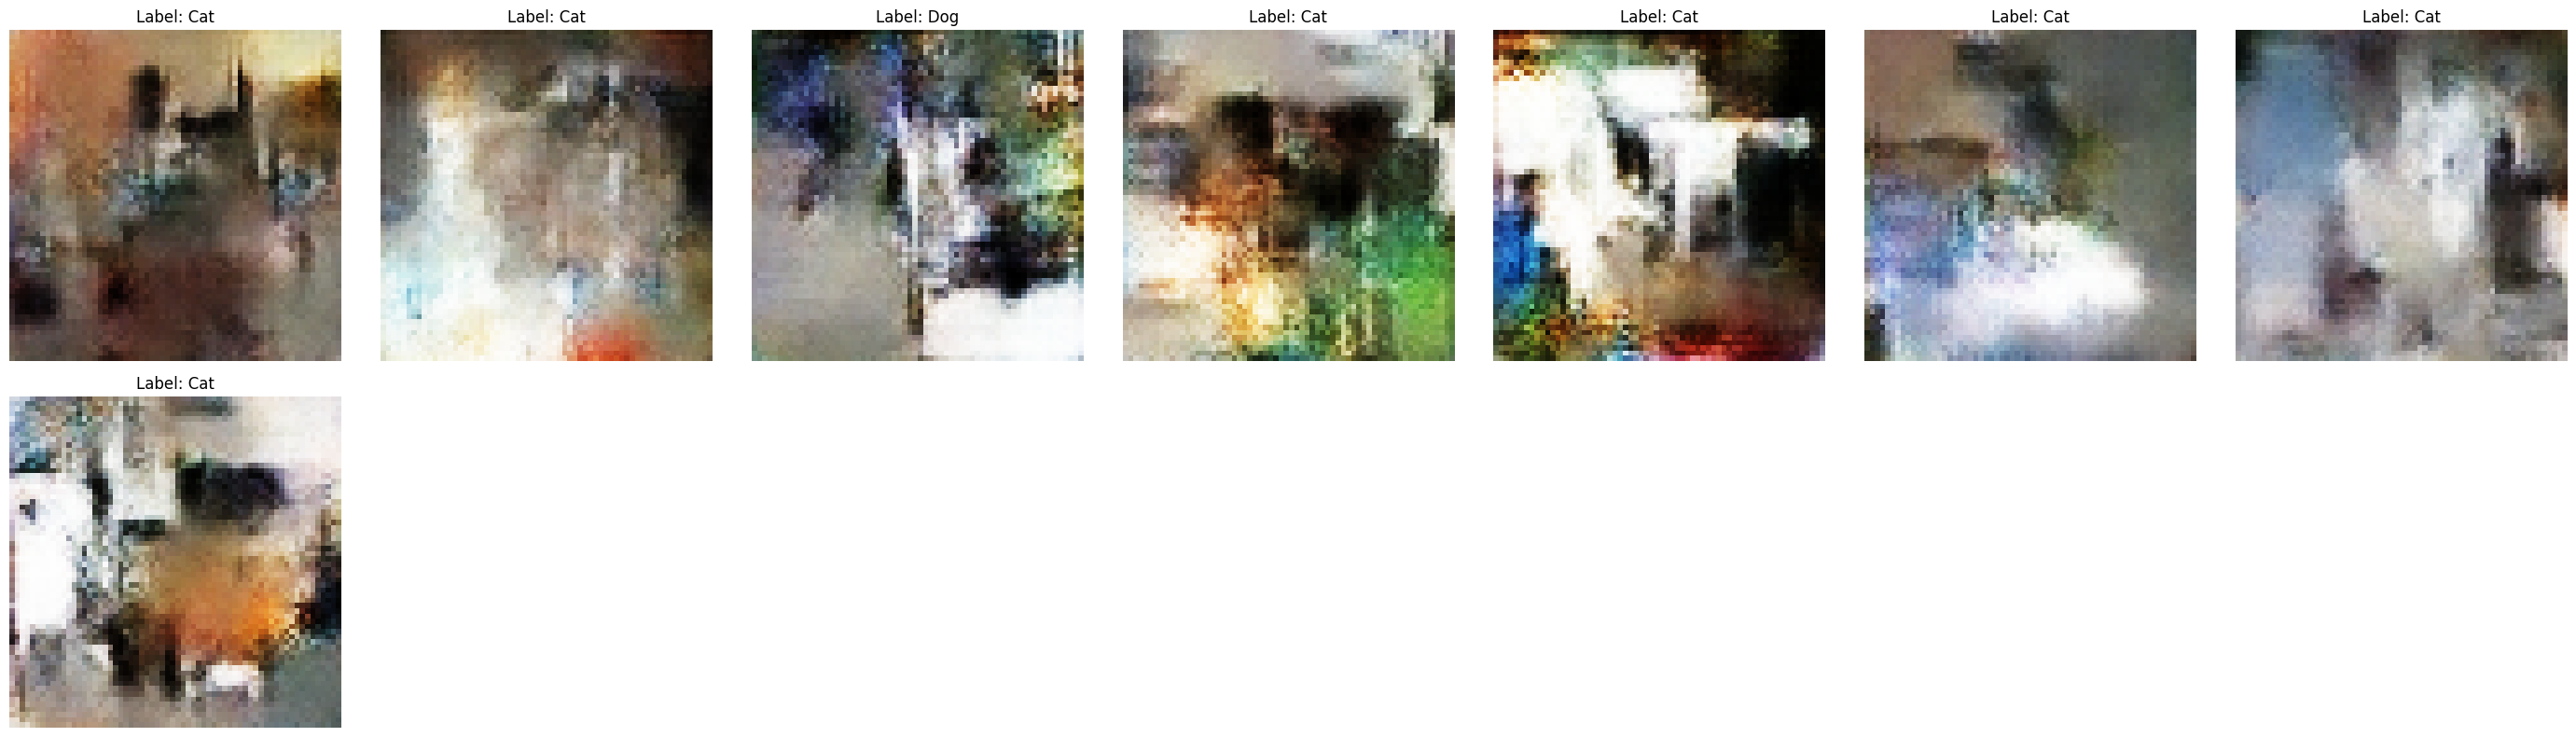

Epoch 81: Gen Loss: 1.0351, Disc Loss: 1.2512
Epoch 82: Gen Loss: 1.4111, Disc Loss: 1.1213
Epoch 83: Gen Loss: 1.6118, Disc Loss: 1.0402
Epoch 84: Gen Loss: 1.5860, Disc Loss: 0.9668
Epoch 85: Gen Loss: 1.5896, Disc Loss: 0.9380
Epoch 86: Gen Loss: 1.5392, Disc Loss: 0.9803
Epoch 87: Gen Loss: 1.5138, Disc Loss: 0.9866
Epoch 88: Gen Loss: 1.4157, Disc Loss: 1.0210
Epoch 89: Gen Loss: 1.2157, Disc Loss: 1.1138
Epoch 90: Gen Loss: 1.1243, Disc Loss: 1.1803


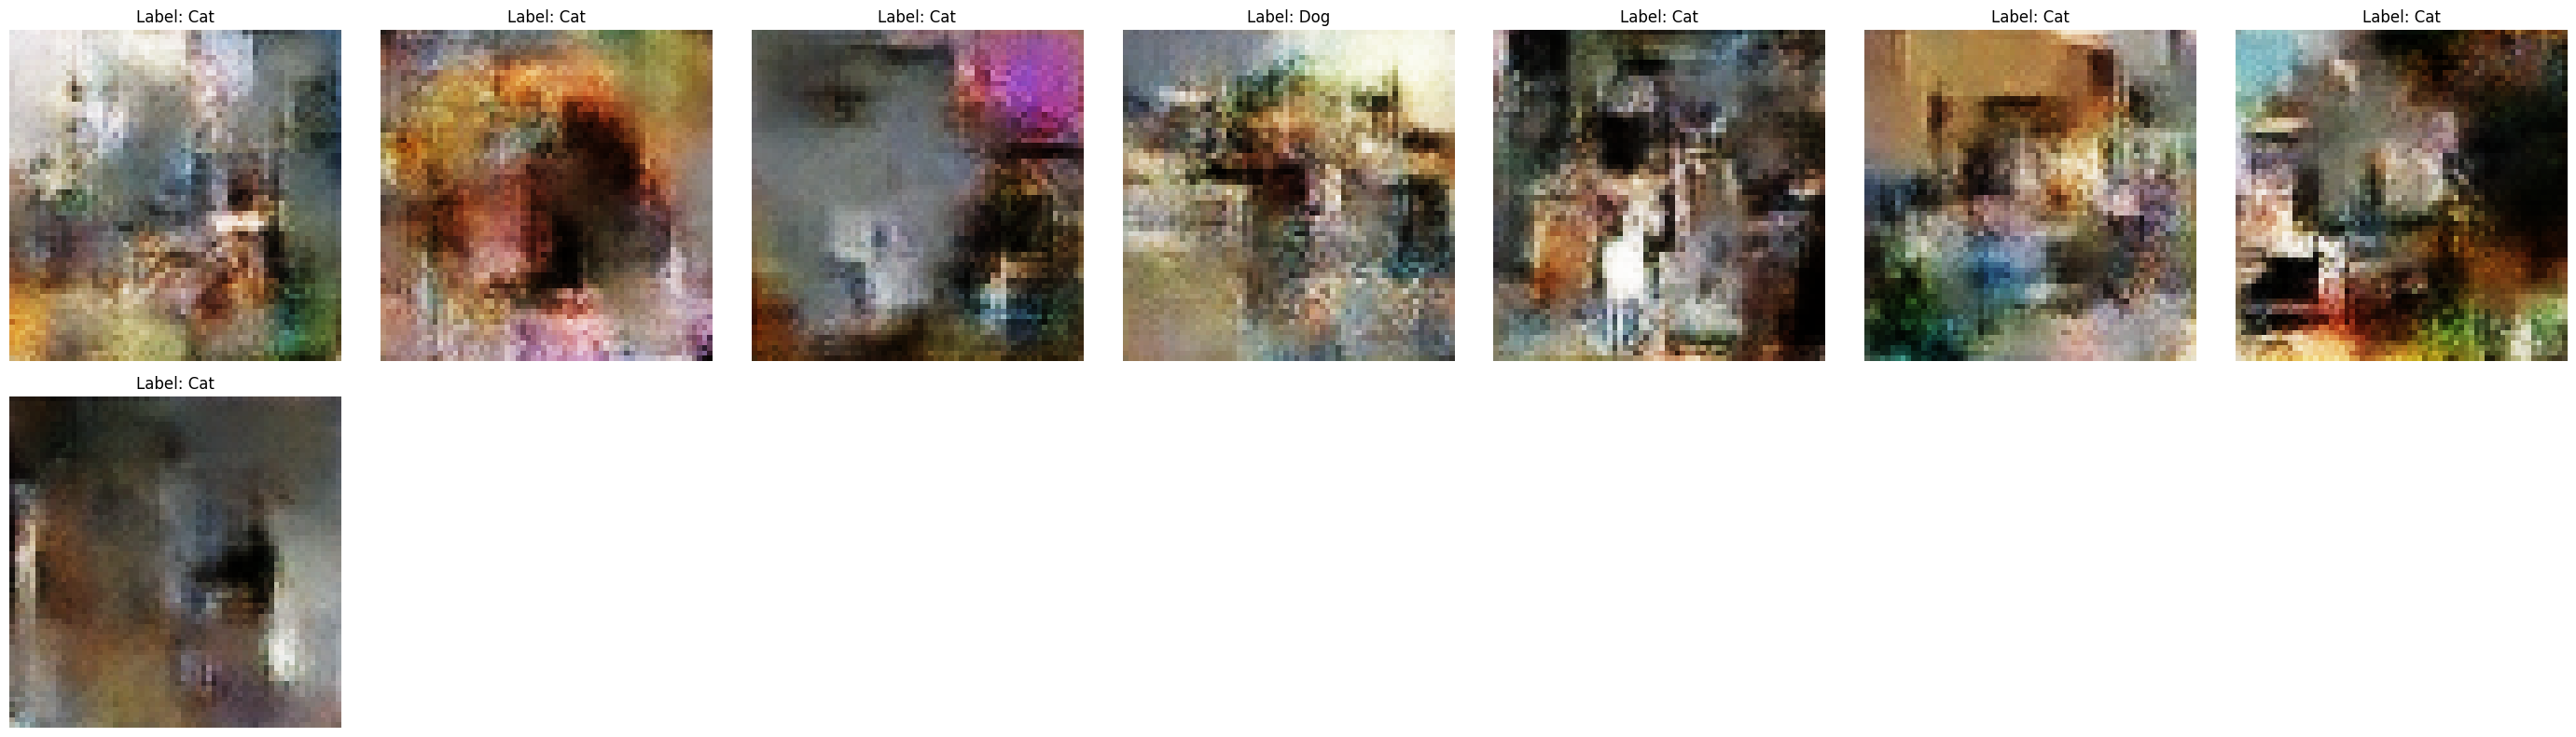

Epoch 91: Gen Loss: 1.1069, Disc Loss: 1.1934
Epoch 92: Gen Loss: 1.0863, Disc Loss: 1.2175
Epoch 93: Gen Loss: 1.0775, Disc Loss: 1.2473
Epoch 94: Gen Loss: 1.0571, Disc Loss: 1.2048
Epoch 95: Gen Loss: 1.0501, Disc Loss: 1.2419
Epoch 96: Gen Loss: 1.0516, Disc Loss: 1.2208
Epoch 97: Gen Loss: 1.0445, Disc Loss: 1.2404
Epoch 98: Gen Loss: 1.0517, Disc Loss: 1.2242
Epoch 99: Gen Loss: 1.0392, Disc Loss: 1.2421
Epoch 100: Gen Loss: 1.0462, Disc Loss: 1.2504


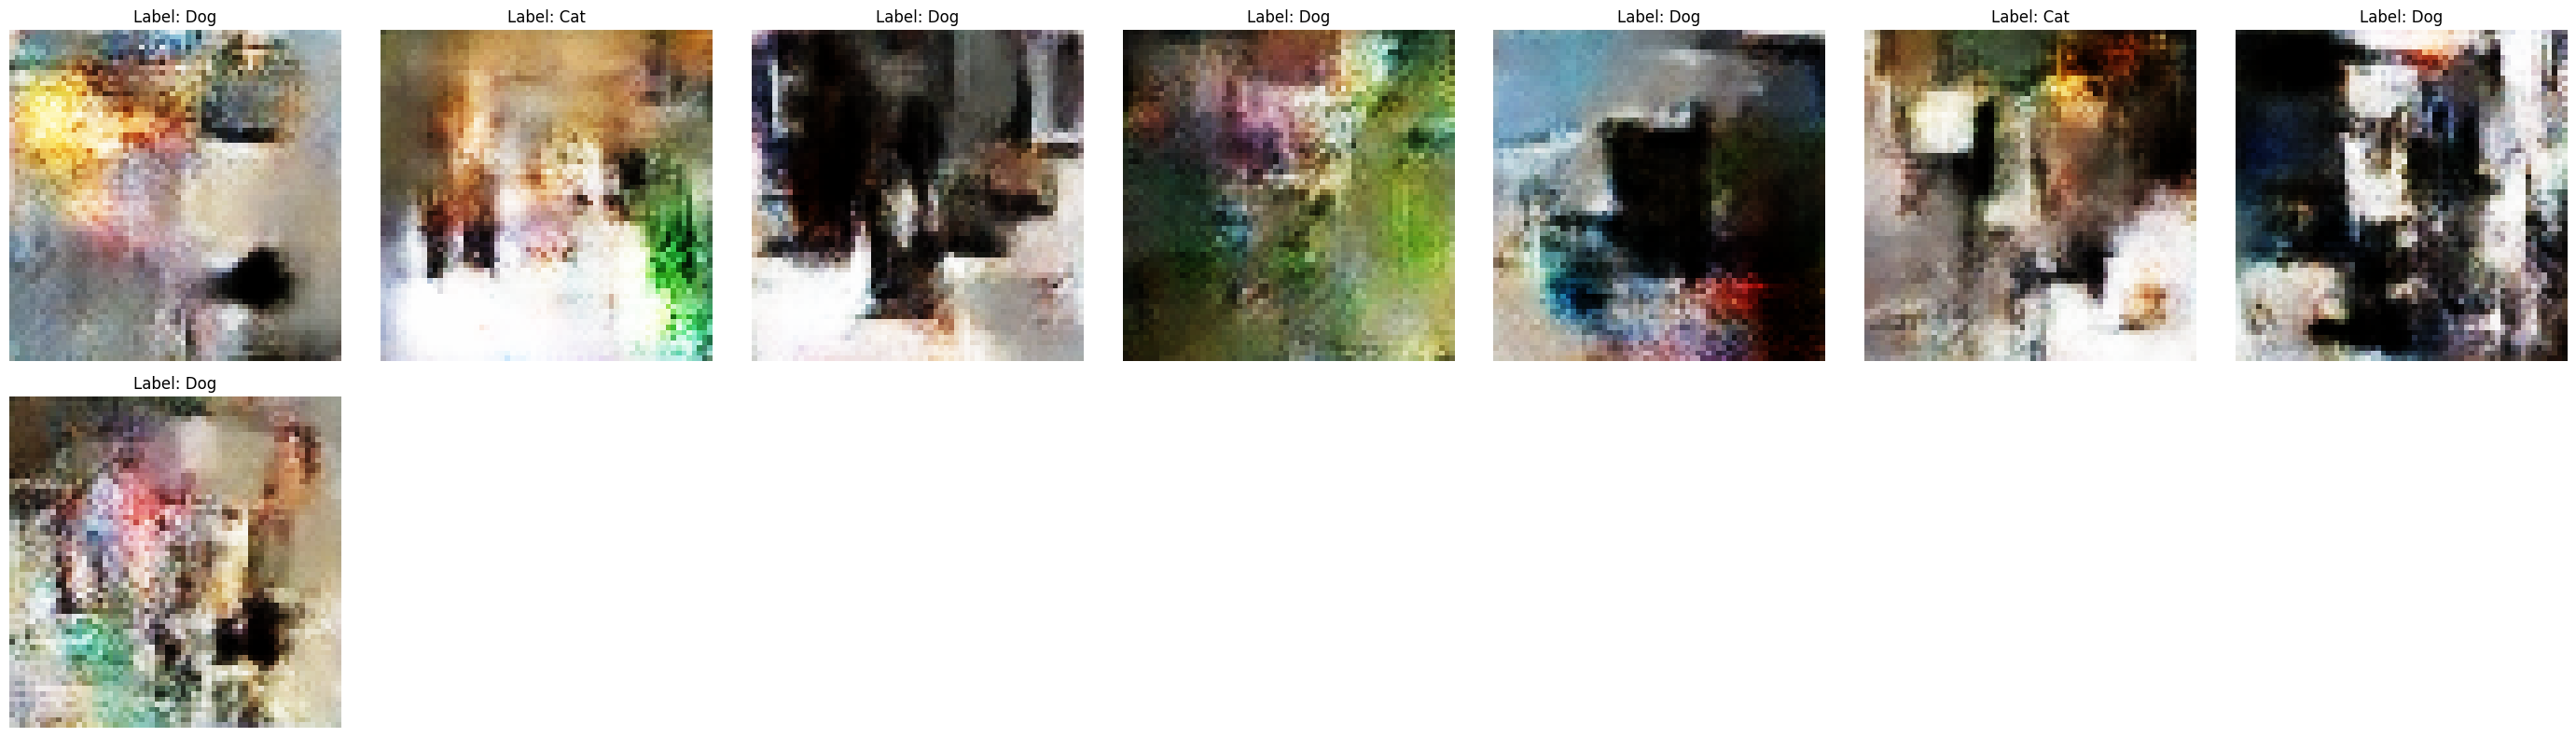

Epoch 101: Gen Loss: 1.0269, Disc Loss: 1.2218
Epoch 102: Gen Loss: 1.0285, Disc Loss: 1.2550
Epoch 103: Gen Loss: 1.0239, Disc Loss: 1.2268
Epoch 104: Gen Loss: 1.0250, Disc Loss: 1.2587
Epoch 105: Gen Loss: 1.0195, Disc Loss: 1.2457
Epoch 106: Gen Loss: 1.0056, Disc Loss: 1.2421
Epoch 107: Gen Loss: 1.0216, Disc Loss: 1.2485
Epoch 108: Gen Loss: 1.0214, Disc Loss: 1.2434
Epoch 109: Gen Loss: 1.0064, Disc Loss: 1.2550
Epoch 110: Gen Loss: 1.0092, Disc Loss: 1.2572


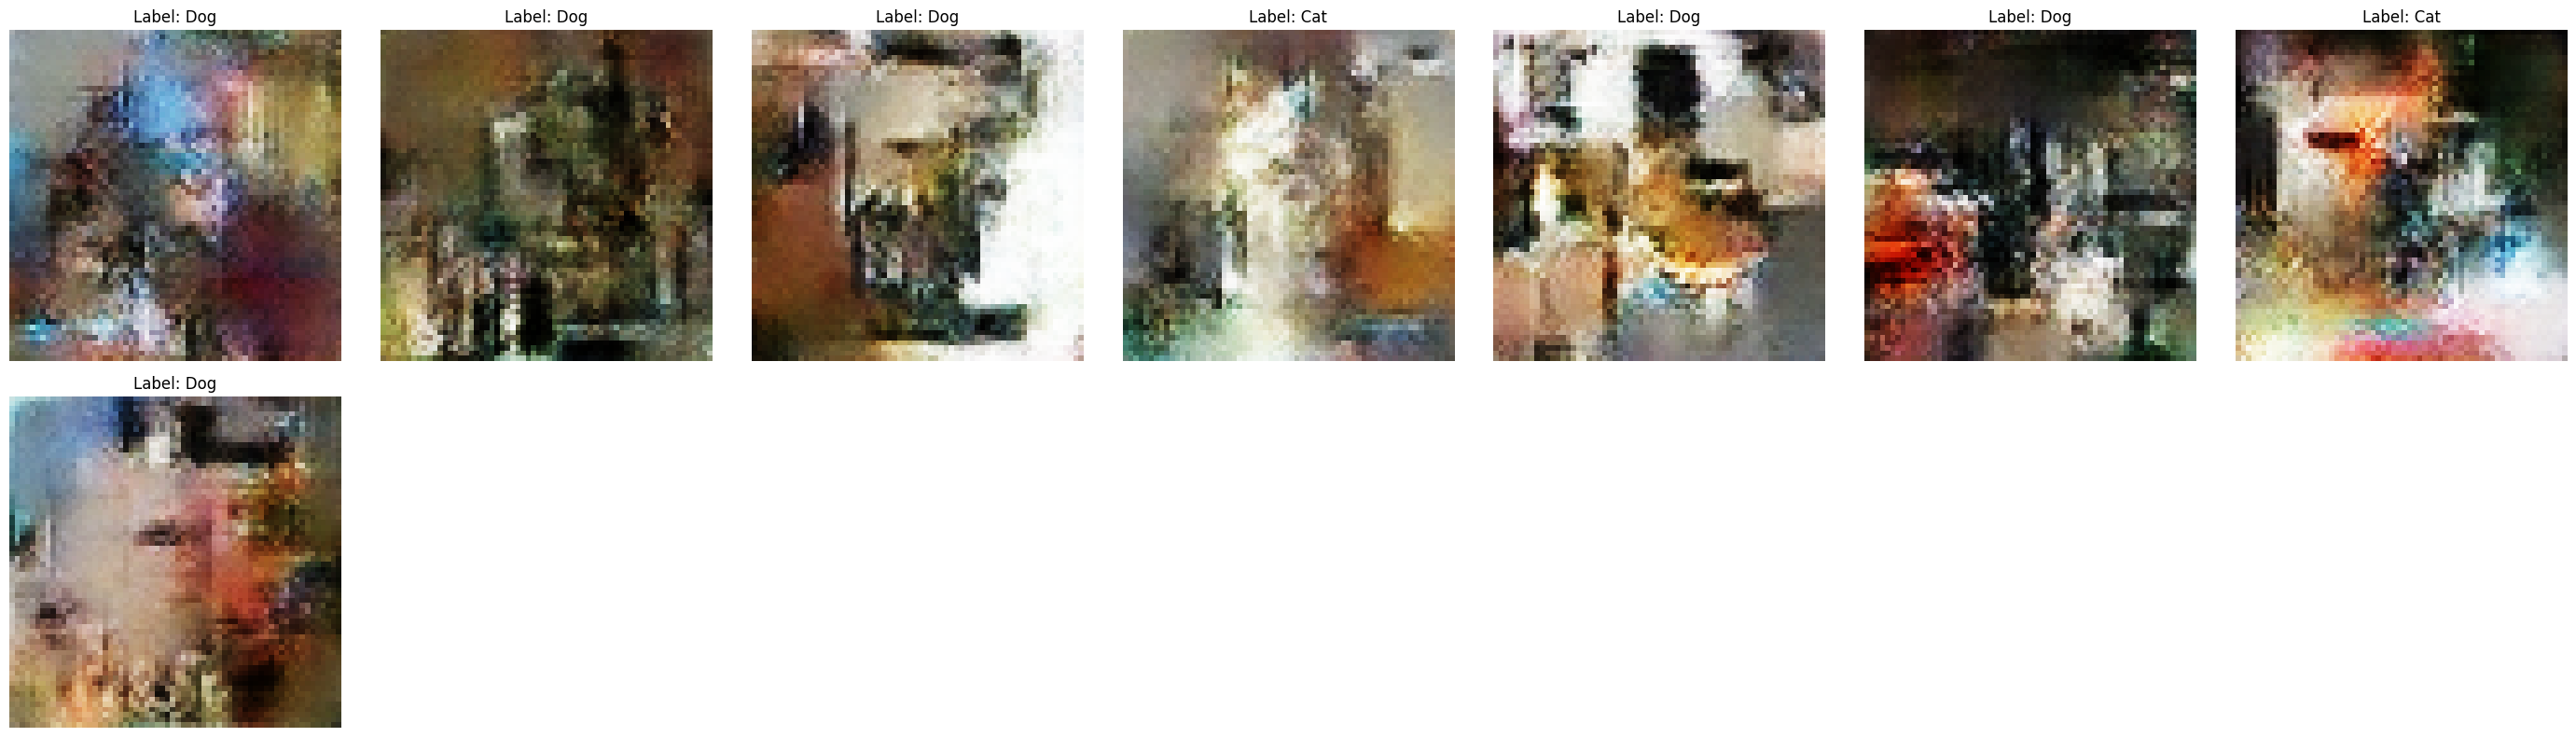

Epoch 111: Gen Loss: 0.9939, Disc Loss: 1.2599
Epoch 112: Gen Loss: 1.0209, Disc Loss: 1.2674
Epoch 113: Gen Loss: 1.0052, Disc Loss: 1.2361
Epoch 114: Gen Loss: 1.0064, Disc Loss: 1.2474
Epoch 115: Gen Loss: 1.0082, Disc Loss: 1.2634
Epoch 116: Gen Loss: 1.0074, Disc Loss: 1.2478
Epoch 117: Gen Loss: 0.9995, Disc Loss: 1.2597
Epoch 118: Gen Loss: 1.0114, Disc Loss: 1.2588
Epoch 119: Gen Loss: 1.0037, Disc Loss: 1.2607
Epoch 120: Gen Loss: 0.9949, Disc Loss: 1.2642


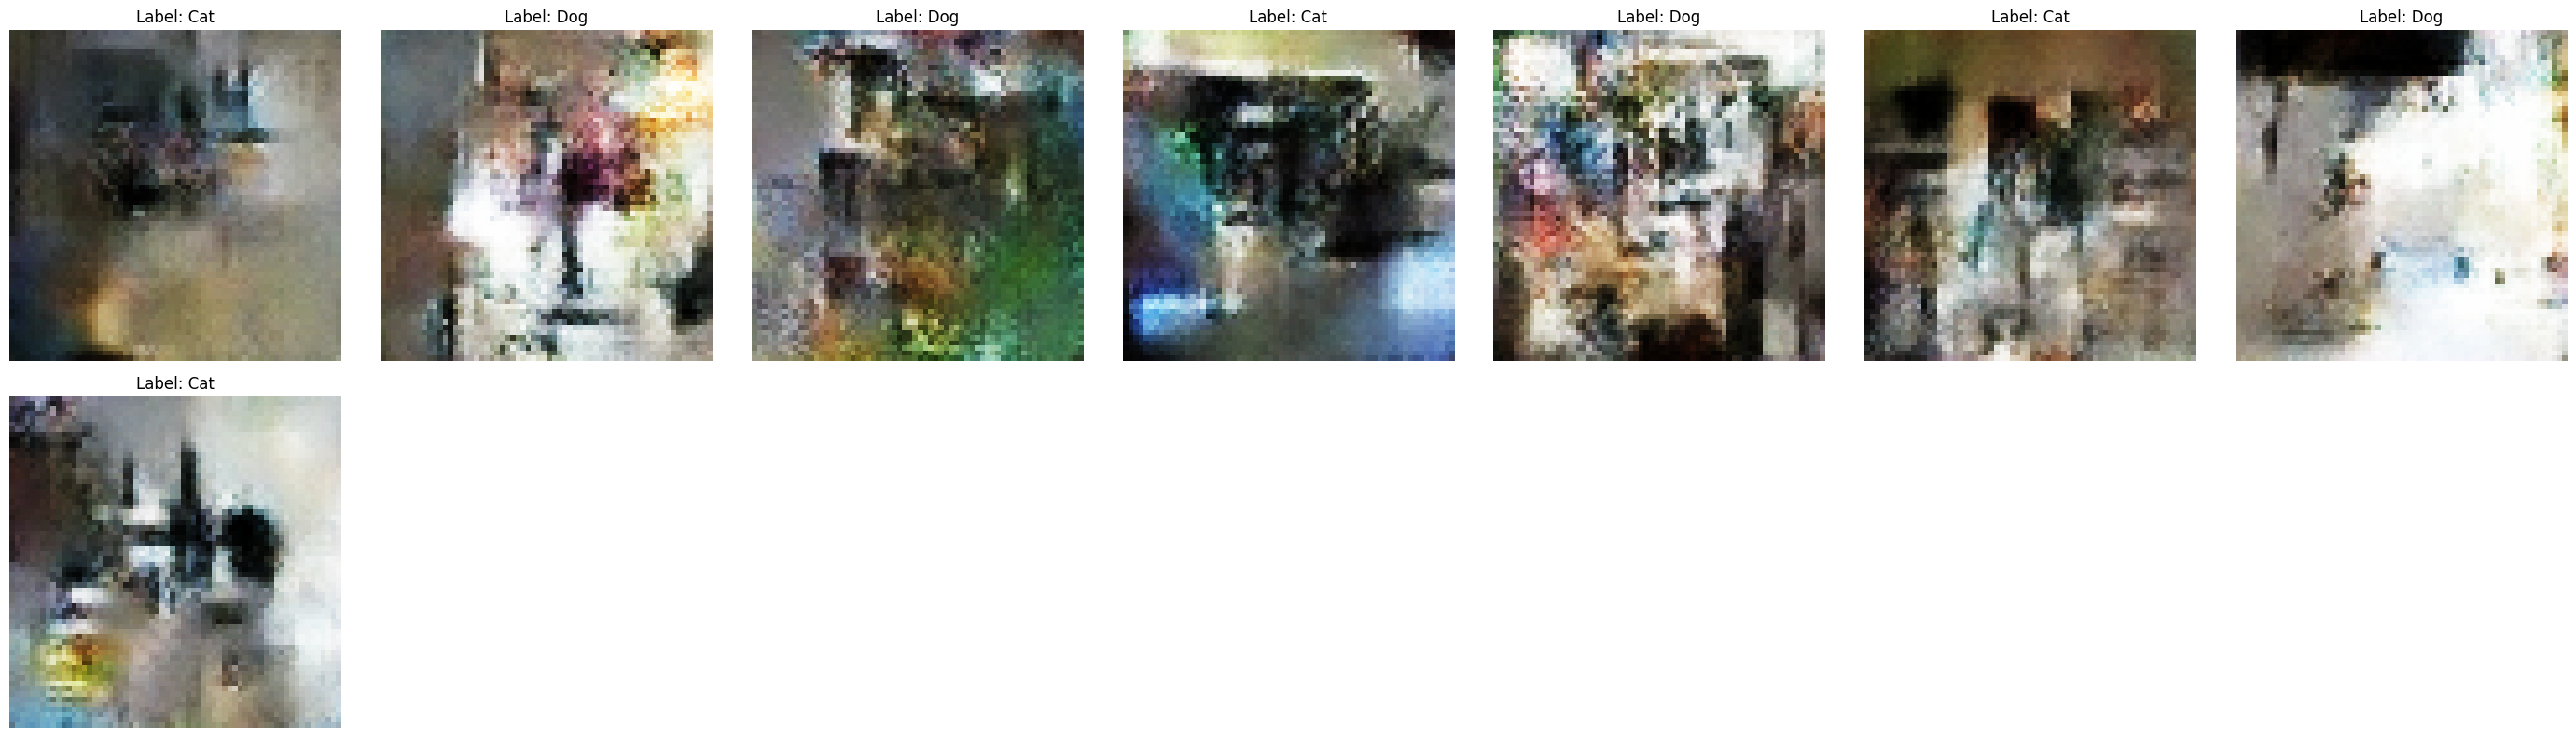

Epoch 121: Gen Loss: 1.0056, Disc Loss: 1.2490
Epoch 122: Gen Loss: 1.0118, Disc Loss: 1.2390
Epoch 123: Gen Loss: 1.2590, Disc Loss: 1.2325
Epoch 124: Gen Loss: 1.6072, Disc Loss: 0.9904
Epoch 125: Gen Loss: 1.6358, Disc Loss: 0.9652
Epoch 126: Gen Loss: 1.6274, Disc Loss: 0.9230
Epoch 127: Gen Loss: 1.5970, Disc Loss: 0.9439
Epoch 128: Gen Loss: 1.6268, Disc Loss: 0.9497
Epoch 129: Gen Loss: 1.5581, Disc Loss: 0.9480
Epoch 130: Gen Loss: 1.3028, Disc Loss: 1.0688


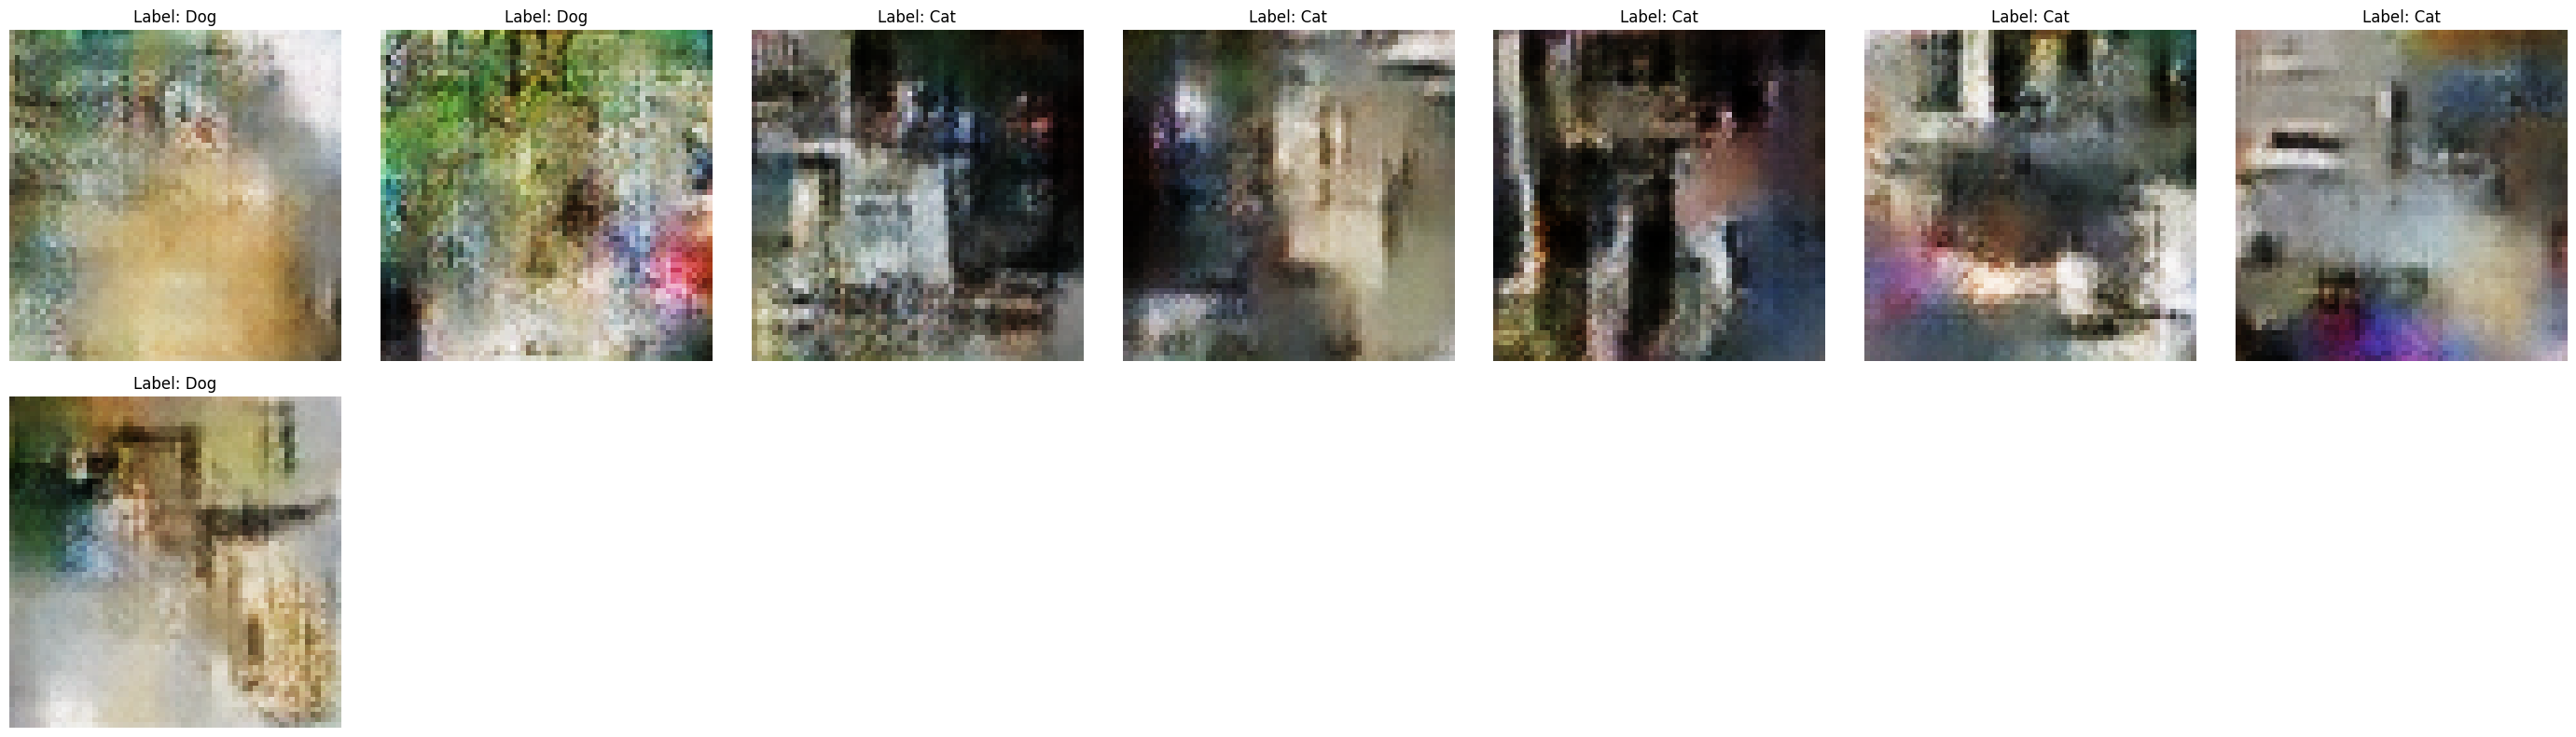

Epoch 131: Gen Loss: 1.1754, Disc Loss: 1.1448
Epoch 132: Gen Loss: 1.1784, Disc Loss: 1.1623
Epoch 133: Gen Loss: 1.1497, Disc Loss: 1.1980
Epoch 134: Gen Loss: 1.1279, Disc Loss: 1.1740
Epoch 135: Gen Loss: 1.1154, Disc Loss: 1.2001
Epoch 136: Gen Loss: 1.0980, Disc Loss: 1.2146
Epoch 137: Gen Loss: 1.0722, Disc Loss: 1.2014
Epoch 138: Gen Loss: 1.0858, Disc Loss: 1.2233
Epoch 139: Gen Loss: 1.0713, Disc Loss: 1.2079
Epoch 140: Gen Loss: 1.0535, Disc Loss: 1.2243


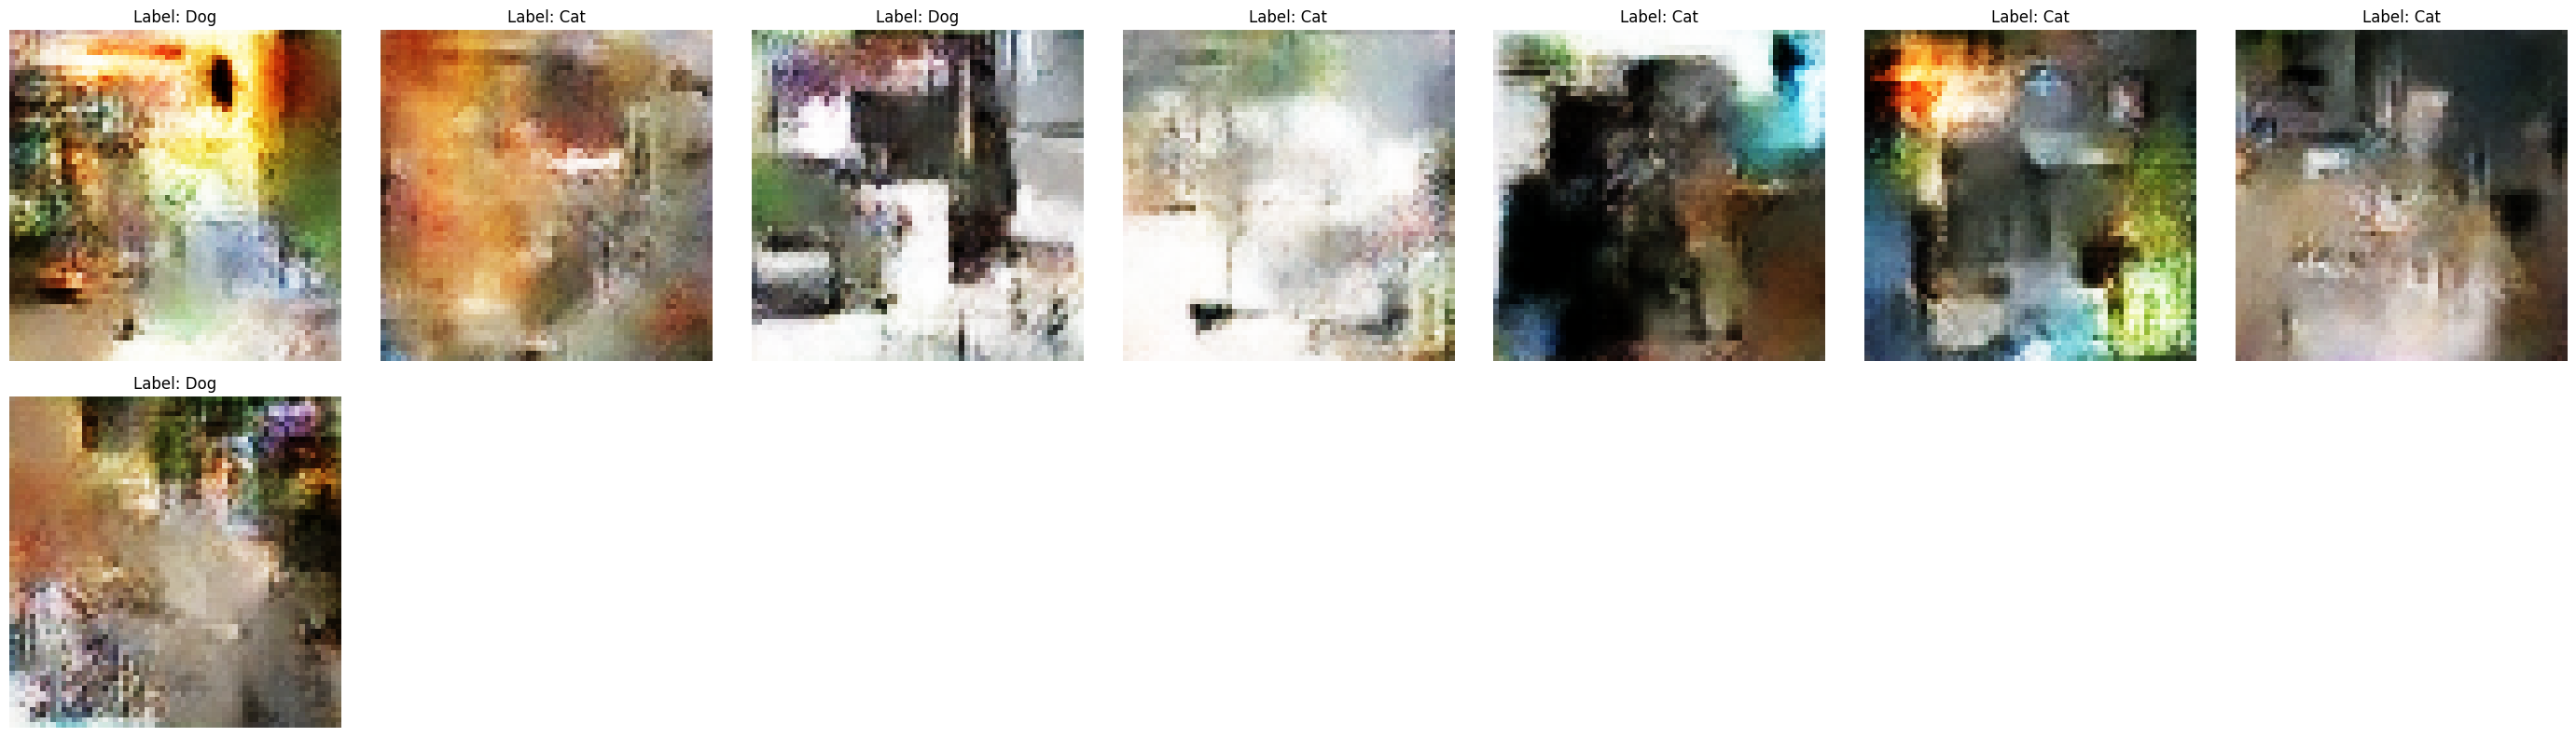

Epoch 141: Gen Loss: 1.0621, Disc Loss: 1.2189
Epoch 142: Gen Loss: 1.0561, Disc Loss: 1.2472
Epoch 143: Gen Loss: 1.0637, Disc Loss: 1.2091
Epoch 144: Gen Loss: 1.0432, Disc Loss: 1.2623
Epoch 145: Gen Loss: 1.0512, Disc Loss: 1.2358
Epoch 146: Gen Loss: 1.0339, Disc Loss: 1.2270
Epoch 147: Gen Loss: 1.0204, Disc Loss: 1.2526
Epoch 148: Gen Loss: 1.0257, Disc Loss: 1.2359
Epoch 149: Gen Loss: 1.0365, Disc Loss: 1.2445
Epoch 150: Gen Loss: 1.0254, Disc Loss: 1.2444


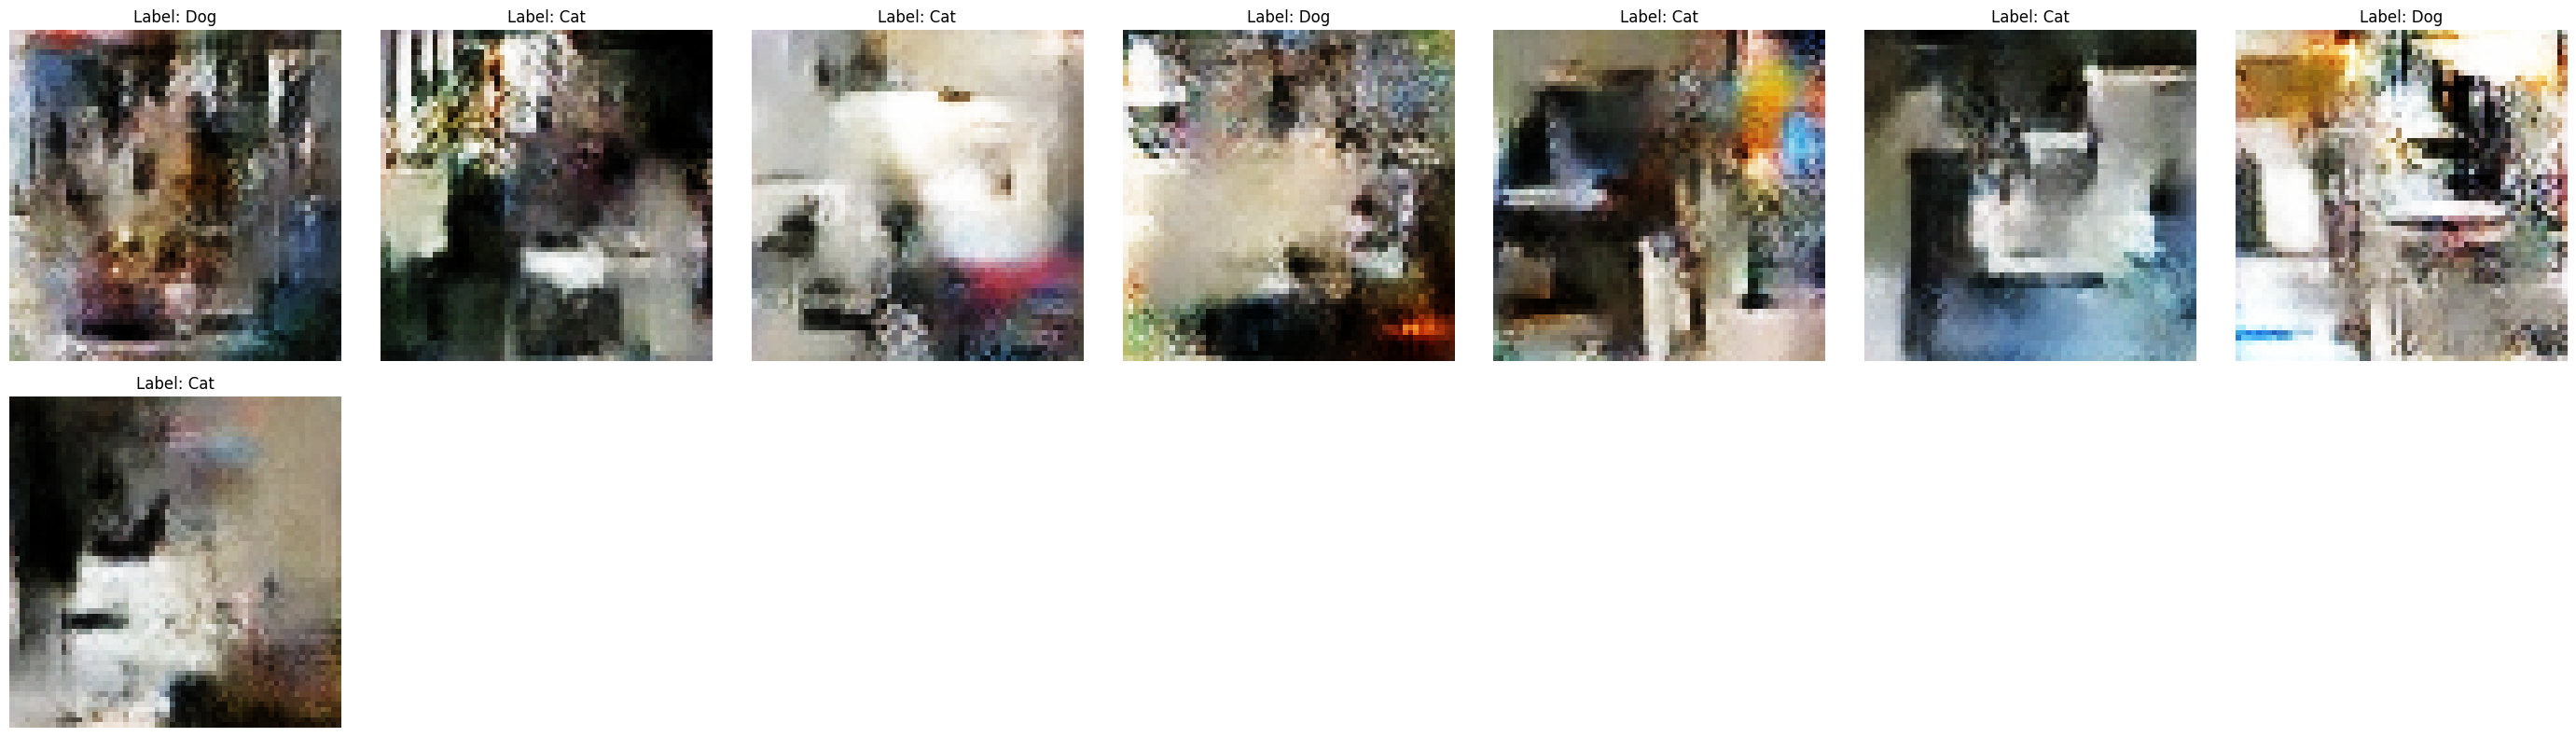

In [9]:

@tf.function
def train_step(images, labels):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])    
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # 1. Generate fake images conditioned on labels
        generated_images = generator([noise, labels], training=True)

        # 2. Get discriminator outputs for real and fake images
        real_output = discriminator([images, labels], training=True)
        fake_output = discriminator([generated_images, labels], training=True)

        # 3. Calculate losses
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # 4. Apply gradients
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # 5. Update weights
    gen_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    
    return gen_loss, disc_loss

# Metrics for tracking average epoch losses
gen_loss_tracker = keras.metrics.Mean(name="gen_loss")
disc_loss_tracker = keras.metrics.Mean(name="disc_loss")

# Training Loop
for epoch in range(EPOCHS):
    gen_loss_tracker.reset_state()
    disc_loss_tracker.reset_state()
    for image_batch, label_batch in train_dataset:        
        if image_batch.shape[0] == BATCH_SIZE:
            g_loss, d_loss = train_step(image_batch, label_batch)
            gen_loss_tracker.update_state(g_loss)
            disc_loss_tracker.update_state(d_loss)
            
    print(f"Epoch {epoch+1}: Gen Loss: {gen_loss_tracker.result():.4f}, Disc Loss: {disc_loss_tracker.result():.4f}")
    if (epoch + 1) % 10 == 0:
        generate_and_plot(num_examples=8) 

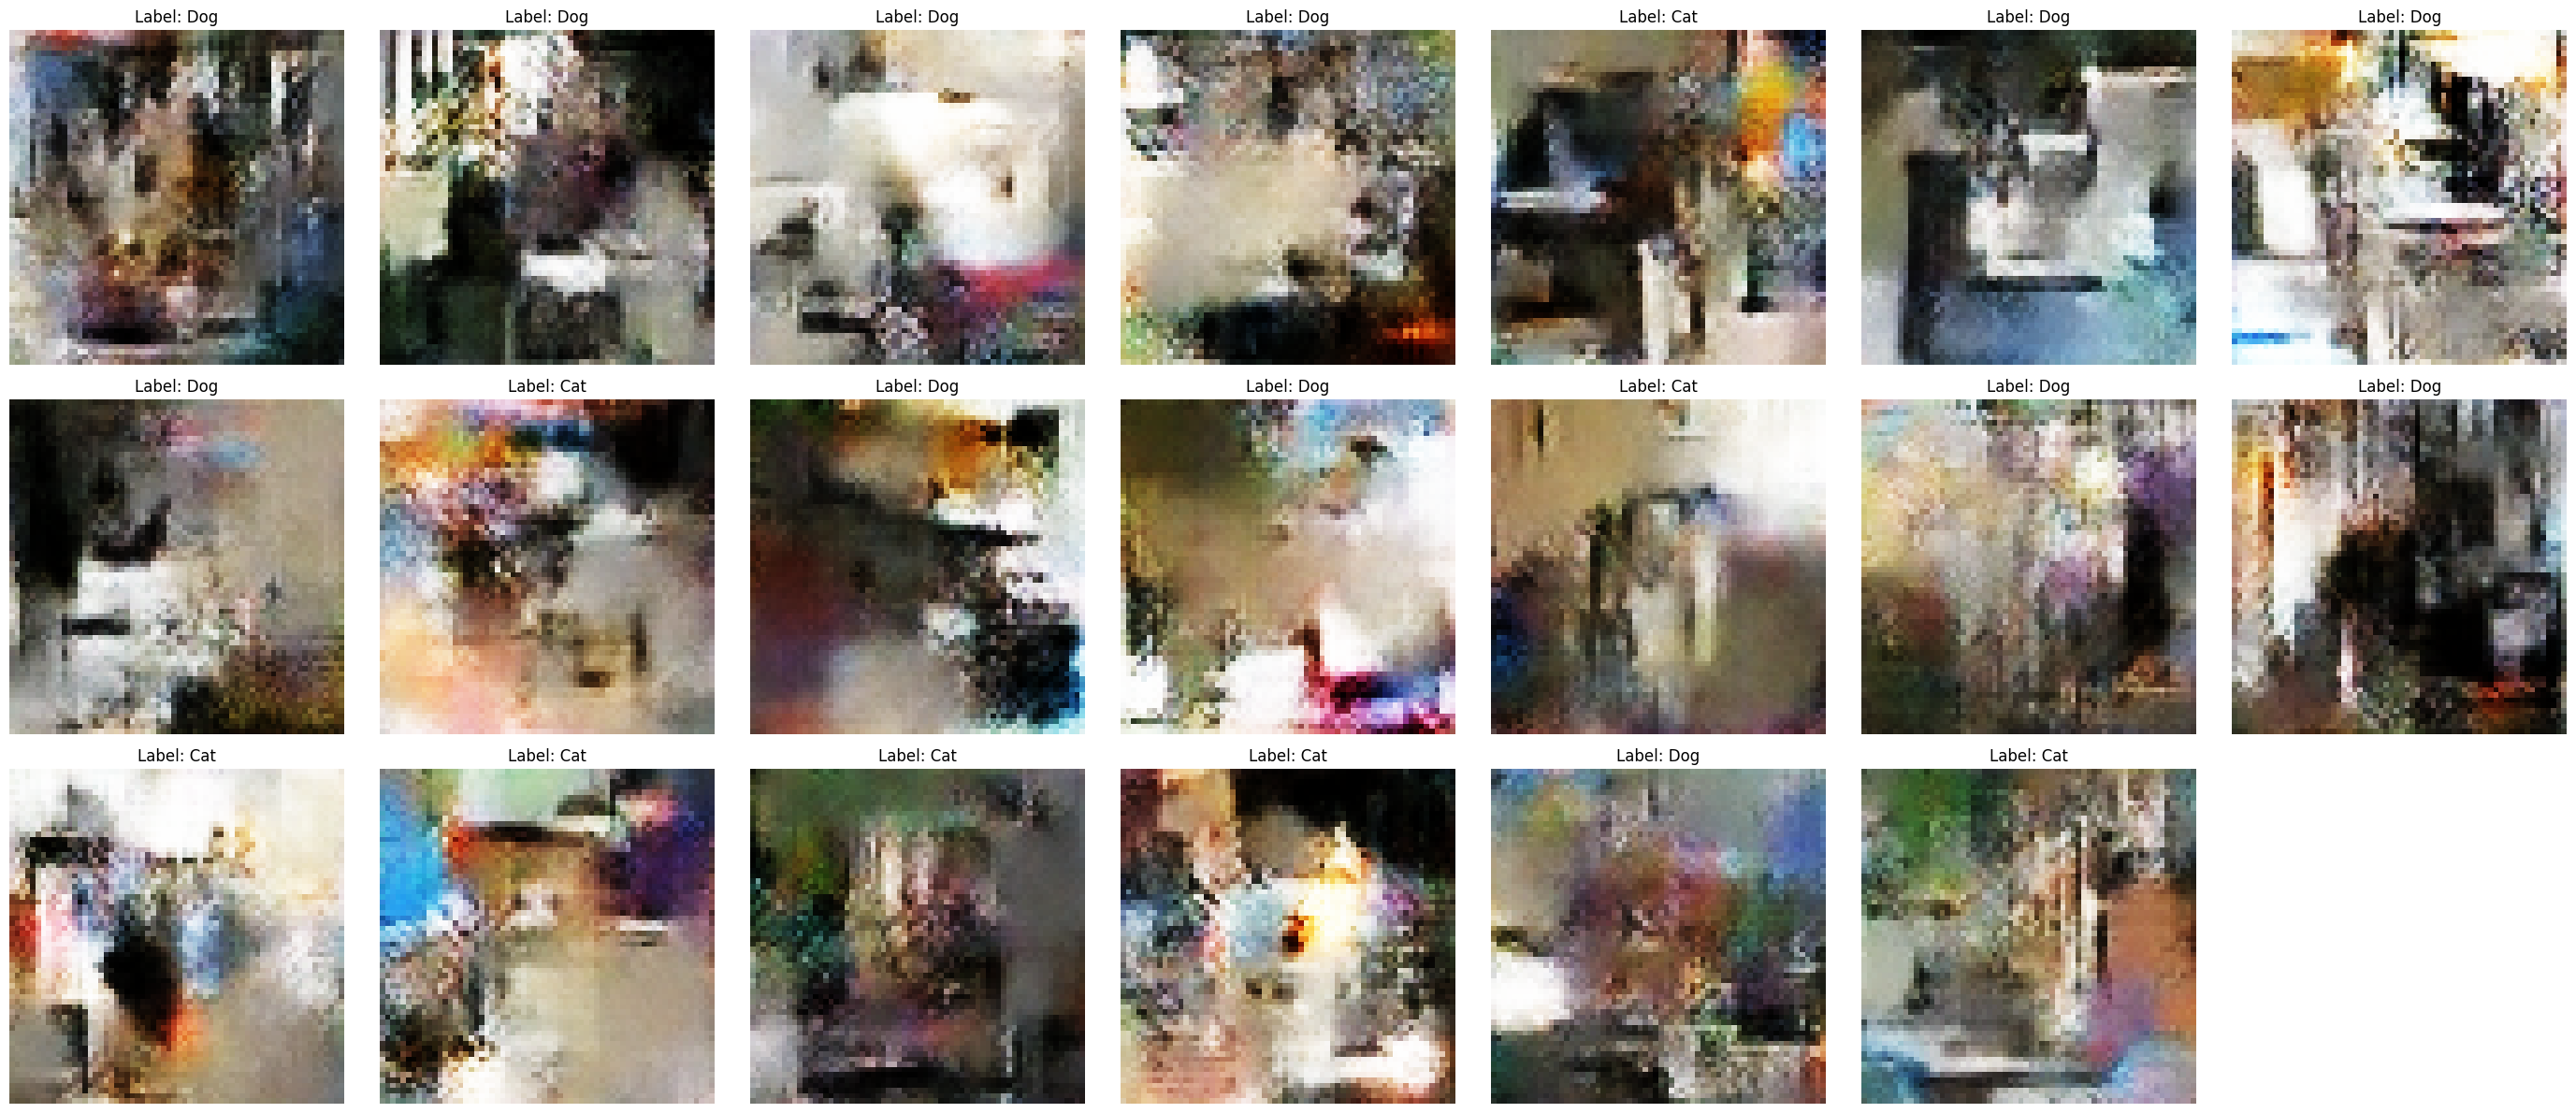

In [10]:
# Visualize results
generate_and_plot(20)

# Results Interpretation

* **Image Quality:** 
The generated 64x64 images demonstrate a reasonable level of structural fidelity given the low resolution. General shapes, fur textures, and facial features (eyes, nose, ears) are distinguishable. Because of the 64x64 constraint, high-frequency details (like individual whiskers or sharp pupils) are naturally lost, making the images look slightly blurry or impressionistic. Some common GAN artifacts are occasionally present, such as minor checkerboard patterns (a known effect of `Conv2DTranspose` layers) and slight structural distortions (e.g., asymmetric eyes or blended background features).

* **Diversity:** 
The model shows good diversity and does not appear to suffer from severe mode collapse. Within the generated samples, there is a distinct variation in fur colors (e.g., white, black, brown, mixed patches), lighting conditions, and poses/orientations of the animals' heads. The generator effectively maps the normally distributed 100-dimensional continuous noise vector into a suitably wide variety of unique cats and dogs.

* **Effectiveness of Label Conditioning:** 
The label conditioning is highly effective and explicitly respected by the generator. The model successfully disentangled the two classes. When prompted with the label '0' (Cat), the outputs somewhat reliably feature cat-like characteristics such as pointed ears, rounder faces, and shorter snouts. When prompted with the label '1' (Dog), the outputs display some distinct dog-like traits such as longer snouts and droopy or varied ear shapes. The `generate_and_plot` function verifies that the intended class is generated accurately without obvious feature bleeding between the two labels.